# Softband fix and incoherence forensics at 150,000

> **Re-verified 2026-08-10** against the *merged* trade-executor
> [#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621). This notebook was
> originally run against the fix branch in a worktree, before the PR landed. Re-running it on
> merged master reproduces **31 of 33 output tables byte-identically**, the two exceptions carrying
> only data-freshness metadata - confirming the merged code matches the build the diagnosis was
> made on.

Based on `72-backtest-inverse-variance-33pct-concentration.ipynb` for the harness, targeting the
two defects NB73 exposed. Its headline configuration is deliberately **NB73's worst incoherent
cell** - 90d lookback / 8 vaults / 50% concentration / 15% pool cap / $375 band, `inverse_variance`
sizing, 150,000 bankroll - so every chart and diagnostic in the notebook body (equity curve, asset
weights, cash deployment, per-cycle alpha-model reports) shows the pathology, not a healthy run.

## Part 1 - fix the softband crash

NB66 diagnosed the mechanism: trims dropped by `sell_rebalance_min_threshold` were still counted as
funding for the same cycle's buys, so a wide band overspends the reserve and dies with
`OutOfSimulatedBalance`. The crash boundary sat between 1% and 2% of capital at every bankroll, and
it cost NB73 a third of its search budget.

**The fix already exists in the library and had never been enabled.**
`generate_rebalance_trades_and_triggers()` carries an opt-in `cap_buys_to_sync_cash` whose
docstring names this exact phantom-funding defect; with it on, buys scale down to current cash plus
the sell proceeds that survive the softband filter, less `sync_cash_headroom_usd`. This notebook
turns it on (`Parameters.cap_buys_to_sync_cash = True`), A/Bs it against a known-crashing
configuration, re-runs the previously fatal $750-$6,000 ladder, and measures what the cap costs on
a healthy configuration.

## Part 2 - locate the incoherence

NB73 found 41 of 108 evaluations completed with books that do not balance - median 12.6% of capital
unaccounted, worst 94.6% - concentrated at loose concentration/pool caps but present across the
space, and **not** explained by the softband (the gap distribution is flat across bands).

The forensic chain, each step narrowing the defect:

1. **Deterministic repro** - run the worst cell through plain `run_backtest_inline`. Raising vs
   completing-incoherent splits the fault between `ignore_wallet_errors` and the core engine.
2. **Accounting identity** - `final equity = initial + realised + unrealised - fees`, the NB73
   check, now packaged as `audit_accounting()` for reuse.
3. **Cycle-by-cycle conservation** - NAV reconstructed from market moves + execution gaps,
   overlaid on actual NAV; step versus slope, and the first cycle where the books break.
4. **Per-trade double entry** - executed price against same-day close for every vault trade;
   cumulative leak compared against the accounting gap. Prime suspect: Hypercore partial
   reductions executing at stale **marked** prices (NB59 measured exactly this) while the
   remainder is valued at the close.
5. **Per-position cashflows** - wallet-truth P&L (cash out vs cash in) against each position's
   claimed realised+unrealised, to catch contradictions like NB73's Gucky_1coi (+$616 unrealised
   on a position whose value is $20,940 below cost).

A control configuration (the NB72 champion) runs through every diagnostic alongside; its residuals
should be ≈ 0.

## Key new insights and what did we learn from this experiment?

### Part 1: the softband crash is fixed, and the fix is free

| Test | Result |
|---|---|
| Crash config, fix OFF | **crashes** at 2026-01-11, $166.82 short - NB73 reproduced |
| Crash config, fix ON | **completes** |
| $750 / $1,500 / $3,000 / $6,000 ladder, fix ON | **all four complete** - $3,000 and $6,000 had crashed at every bankroll ever tested |
| Cost on a healthy configuration | **+0.00% CAGR** at both the $5 and $750 bands |

`cap_buys_to_sync_cash=True` closes the phantom-funding defect exactly as its docstring promises,
and costs nothing when the band is narrow because the cap never binds. **This should be enabled in
every notebook in this chain from here on.** The crash class that consumed a third of NB73's search
budget is closed by a two-line change.

### Part 2: the incoherence is a unit bug in the Hypercore dust-close epsilon

The forensic chain eliminated the suspects one by one:

| Hypothesis | Test | Verdict |
|---|---|---|
| `ignore_wallet_errors` corrupts state | plain `run_backtest_inline`, no flag | **dead** - reproduces to the cent ($10,645.43) |
| Stale-mark execution prices (NB59) | per-trade executed price vs same-day close | **dead** - total leak $766 = 1% of the $137,822 gap; every sell within ~0.10% of close (= the fee) |
| Softband phantom funding | gap flat across softband values (NB73) | **dead** |
| NAV bookkeeping drift | conservation audit | books break by the **fourth cycle** (2026-01-07), residual is a slope, not a step |

What the cashflow audit then found: **34 closed positions with cash out and no cash in - $111,120
written off**, 81% of the gap, almost all pmalt (15) and Citadel (14), recurring 2-4 times per
cycle from 2026-02-10 onwards. Anatomy of the largest:

> Position #60, pmalt: one successful buy - 701.15 shares, $8,963.78 debited - then the position is
> **marked closed at the same timestamp, still holding all 701 shares, valued at $0**. No sell, no
> balance update, realised P&L $0.

### Root cause, to the line

`tradeexecutor/strategy/dust.py`:

```python
HYPERLIQUID_VAULT_CLOSE_EPSILON_CAPITAL_PCT = Decimal("0.005")
def get_hyperliquid_vault_close_epsilon(initial_cash):
    ...
    return Decimal(str(initial_cash)) * HYPERLIQUID_VAULT_CLOSE_EPSILON_CAPITAL_PCT
```

`runner.py:720` stamps this onto every open Hypercore position each cycle, and
`TradingPosition.can_be_closed()` compares it against **`get_quantity()` - share units**:

```python
return abs(quantity) <= epsilon
```

**The epsilon is derived from dollars and applied to shares.** At 150,000 it is 750 *shares*,
whatever the share price. The moment a buy settles, `state.py:1056` checks `can_be_closed()` and
`portfolio.close_position()` - which is bookkeeping-only, "does not sell anything" - writes the
position off as dust:

| Vault | Share price | 750 shares = | Effect |
|---|---:|---:|---|
| pmalt | $12.78 | **$9,588** | every buy under $9.6k destroyed on arrival; the audit shows them all at $5-9k |
| Citadel | $5.78 | **$4,335** | 14 positions destroyed |
| Realist Capital | $2.94 | $2,208 | NB73's "zero-duration position", exactly |
| Scared Mon | $0.000016 | $0.01 | never affected - millions of shares |

It also bites *partially*: pmalt position #21 traded normally ($62,761 in, $57,401 out) until the
residual dropped under 750 shares, at which point the remaining **$6,415** was written off at close.

The intent bug is visible in the constants: the default epsilon of 2.00 is documented against a
"$1.50 in 6-decimal USDC" withdrawal margin - it was always *meant* as dollars. For vault shares
priced near $1 the units coincide and nothing is noticed. pmalt at $12.78 breaks the coincidence,
and scaling the epsilon by bankroll (`initial_cash x 0.005`) weaponised it: at 25,000 the threshold
is 125 shares (~$1,600 of pmalt, below typical trade sizes - rare), at 150,000 it is 750 shares
(~$9,600 - catches almost every pmalt entry). **That is why NB63/NB64 at 25,000 reconcile to 0.3%
while half of NB73's search was incoherent.** The function even carries a TODO admitting the
missing clamp.

### Blast radius, as predicted and as measured

This section originally predicted that *"every 75,000 and 150,000 result in NB66-NB73 carries some
contamination"*. **That was too broad.** All four affected notebooks were re-run against the fixed
library and only one changed:

| Notebook | Bankroll | Post-fix outcome |
|---|---:|---|
| NB67 capacity 2x2 | 75k / 150k | **Identical.** Audit confirms all four cells coherent, residual -0.16% to -0.01%, 0 destroyed positions |
| NB68 breadth 6/7/8 | 75k / 150k | **Identical** on every metric and deployment stat |
| NB72 inverse_variance | 150k | **Identical** ($169,244 vs $171,143, +2.77 pp margin unchanged) |
| NB73 joint search | 150k | **Materially changed.** Crashes 33 -> 11, incoherent 41 -> 15, sound 34 -> 82, best Sharpe 1.39 -> 2.76 |

So the conclusions of NB67, NB68 and NB72 stand as published. Only NB73 was corrupted, and it was
corrupted badly enough to have found the wrong optimum.

**Why the fixed-configuration notebooks escaped.** Bankroll alone was not the trigger, and neither
was `inverse_variance` - both were hypotheses here, and both are now falsified. What matters is
whether a configuration ever holds a position small enough in *share count* to fall under the
threshold. NB67, NB68 and NB72 pin their allocation parameters to values that keep every pmalt
holding above it; NB73 searches a space that includes wide baskets and tight caps, which produce
exactly the small holdings that trip the bug. The damage is **configuration-dependent, not
capital-dependent** - which is precisely why a parameter search was the thing it destroyed.

- **25,000-bankroll results (NB58-NB65 and all optimiser notebooks through NB64) are clean** - the
  audit residual is ~0.3% after fees, and the threshold at that bankroll (125 shares, ~$1,600 of
  pmalt) sits below typical trade sizes.
- **The bias is downward** where it lands: the bug destroys value, so affected configurations
  *understated* true performance. NB73's best CAGR rose from 31.84% to 48.92% once fixed.
- **A residual gap survives in NB73**: 15 of 108 runs still miss the identity, but by 1.2-2.0% of
  capital rather than a median of 12.6%. They cluster on 7-8 vault baskets. That is a separate,
  much smaller effect and it remains open.

### Post-fix verification

Both defects are now fixed: the softband crash by enabling the library's existing
`cap_buys_to_sync_cash` flag, and the incoherence by trade-executor
[#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621). Re-running this notebook
against the fixed library, same configuration:

| | Before | After |
|---|---:|---:|
| Final equity, worst NB73 cell | $10,645 | **$163,634** |
| Unexplained vs `initial + realised + unrealised - fees` | **-91.88%** | **+0.77%** |
| Coherent? | No | **Yes** |
| Positions closed with cash out and no cash in | 34 ($111,120) | **0 ($0)** |
| Control (NB72 champion) residual | -5.83% | **-0.14%** |

The single worst configuration recovers **$152,989** of destroyed value, and the control - which
was itself leaking 5.8% - now reconciles to within a rounding residual.

The library fix is two parts: the USD close threshold is converted to share units at the mark price
before being compared against a quantity, and the capital-scaled threshold is clamped to 50 USD. A
second guard refuses to book-close any position still holding more than 100 USD unless the caller
opts in, so a future mis-scaled threshold raises instead of silently deleting a position.

**That guard immediately earned its place.** Set initially at 25 USD it fired on a *legitimate*
close - a 31.36 USD IKAGI residual that the 50 USD dust ceiling considers negligible - revealing
that the two thresholds contradicted each other. The limit now sits above the dust ceiling and the
invariant is asserted in the test suite. A unit-test-only workflow would have shipped a guard that
blocks correct behaviour in production.

## Summary of results

| Question | Answer |
|---|---|
| Softband crash fixed? | **Yes** - `cap_buys_to_sync_cash=True`, verified on the full ladder, zero cost |
| Incoherence fixed and verified? | **Yes** - trade-executor #1621; this notebook now reconciles to +0.77% |
| Incoherence source found? | **Yes** - Hypercore dust-close epsilon in share units, scaled from dollars |
| Where | `dust.py get_hyperliquid_vault_close_epsilon()` -> `runner.py:720` -> `can_be_closed()` -> `state.py:1056` -> bookkeeping `close_position()` |
| Magnitude in the repro | $111,120 of $137,822 in 34 instant write-offs + partial residual write-offs |
| Independent of `ignore_wallet_errors`? | **Yes** - reproduces to the cent in a plain inline run |

## Robustness of results

- **The repro is deterministic to the cent**: the inline run lands on $10,645.43, identical to
  NB73's optimiser-path state, so nothing here depends on the search harness.
- **The accounting identity caught what four notebooks of analysis machinery missed**, and the
  1% tolerance is now known to be too loose: NB73's 34 "sound" runs pass it while still containing
  sub-threshold instances of this bug (the Realist Capital write-off was 1.5% of capital).
  `audit_accounting()` should run in every notebook, with the zero-proceeds position scan beside it.
- **The per-trade forensics also positively cleared execution pricing**: every sell within ~0.10%
  of close means the fee is applied correctly and there is no stale-mark leak at this cadence -
  worth knowing independently of the bug hunt.
- **The control being dirty (-5.8%) strengthens the diagnosis** - it holds pmalt - but it means no
  150,000 configuration measured so far is a trustworthy baseline until the fix lands.
- The conservation audit's residual-vs-gap arithmetic double-counts nothing: market moves sum to
  $0 for the worst config because its valuation updates barely ran before positions were destroyed.

## What to do about it

1. **Fix `can_be_closed()` in trade-executor**: the epsilon must be denominated in USD and compared
   against `quantity x share price` (or divided by price before comparing to quantity), with the
   TODO's clamp added so no bankroll can scale it into real-position territory. Add a regression
   test: a high-share-price vault position worth many times the dust threshold must not be
   closeable as dust at any `initial_cash`.
2. **A bookkeeping close must never destroy value silently.** `close_position()` on a position with
   material remaining value should raise, or book the write-off as an explicit realised loss -
   $8,963 vanishing with claimed P&L $0 is the worst possible failure mode.
3. **Enable `cap_buys_to_sync_cash=True` in every notebook** going forward; retire the softband
   crash caveats from NB66/NB67.
4. **After the epsilon fix: re-run NB67, NB68, NB72 and NB73** - capacity, concentration reversal,
   exponent margin and the joint search are all measured on contaminated 75k/150k runs. The 25k
   chain stands.
5. **Make `audit_accounting()` + the zero-proceeds scan standard cells** in this chain.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- Keep the strategy parameters identical to `02-backtest-until-2026-07-09.ipynb`, except reduce initial capital to `25,000 USD`.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '74-research-softband-fix-and-incoherence-diagnostics'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Two-day rebalance cadence, the NB63/NB64 recommendation, expressed natively: the engine
    #: steps every 48 hours. NB64 reached the same schedule by running a sub-daily clock and
    #: skipping cycles with a modulo counter; this notebook does not, so there is no gap between
    #: what the parameter says and what the engine does.
    #:
    #: Passed explicitly to `run_backtest_inline()` below. The inherited call site derived the
    #: cycle from `candle_time_bucket` instead, which would silently ignore this value.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: Six-vault basket for the headline run; 6, 7 and 8 are compared against every weighting
    #: method in the grid below.
    #:
    #: NB35 chose 6 on return and drawdown grounds at a 25,000 bankroll, where capacity was not a
    #: constraint. NB67 then found that at 150,000 the strategy cannot place its capital: 3.32 of
    #: the six signals are pool-capped in the average cycle and CAGR falls from 35% to 27% even
    #: with a 25% pool cap. Breadth is the obvious lever against that - more slots means smaller
    #: positions means the per-vault TVL cap binds later - and it is the one NB67's conclusion
    #: pointed at without testing.
    max_assets_in_portfolio = 8  # NB73's worst incoherent cell
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: Concentration ceiling per position. NB53 moved this from NB36's 0.50 to 0.35 and NB63/NB64
    #: pinned 0.35; 0.33 is a round third, so a six-vault basket needs at least three positions
    #: carrying weight before the cap stops binding.
    #:
    #: NB65's reconciliation measured 0.50 -> 0.35 as worth +5.25 pp of CAGR on this strategy, so
    #: this is the single largest non-cadence lever in the notebook.
    #: 33% concentration ceiling, the value used from NB63 onwards. With six slots it needs at
    #: least three positions carrying weight, so it leaves the sizing rule materially more room
    #: than the 25% cap does - which is the point of running both.
    max_concentration_pct = 0.50  # NB73's worst incoherent cell
    #: Cap position size to this share of vault TVL, raised from the 0.15 used everywhere else in
    #: this chain. At 150,000 a 33% concentration ceiling wants up to $49,500 in one vault, which a
    #: 15% cap only permits for vaults above $330,000 of TVL; a 25% cap brings that down to
    #: $198,000 and lets far more of the universe take a full-sized position.
    #:
    #: This is the lever under test. NB31 showed that removing the cap entirely *hurts* returns, so
    #: 0.25 is a loosening rather than an abandonment: the backtest still does not assume the
    #: strategy can own an unrealistic share of any vault.
    per_position_cap_of_pool_pct = 0.15  # NB73's worst incoherent cell
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: Sell threshold as a fraction of initial cash: **0.5%**, i.e. $750 at this bankroll.
    #: NB62 measured 543 weight-drift trims worth $263k against 99 exits; the softband
    #: suppresses the trims, which are the cheapest turnover to give up.
    #:
    #: Chosen, not searched. NB66 swept the band at two bankrolls and established three things:
    #: the band cannot recover meaningful fee drag at any width (it removes ~56% of trims and ~1% of
    #: redemption volume, because full exits carry ~70% of that volume and no trim threshold
    #: touches them); the crash boundary sits between **1% and 2% of capital** at both 25,000 and
    #: 75,000; and the 1% rung is the *edge* - it completed on one window and crashed on another at
    #: 25,000.
    #:
    #: So 0.5% is picked to remove unnecessary rebalancing rather than to save fee: it drops ~43% of
    #: trims while sitting a factor of four below the failure boundary instead of on it. The sweep
    #: below re-tests 1%, 2% and 4% to confirm the boundary has not moved under the looser pool cap.
    sell_rebalance_min_threshold_of_initial_cash_pct = 0.0025  # $375, NB73's worst incoherent cell

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 180
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.50
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.08
    #: Rolling window for the inverse-volatility sizing weight. NB31: the single
    #: biggest contributor - equal weight halves CAGR and triples drawdown.
    #:
    #: Both that finding and the NB28/NB29 search that chose 60 ran on the 2025-08-01 window, where
    #: 41% of days carry no Hypercore price observation and `load_partial_data()` forward-fills the
    #: gaps. A 60-day volatility estimate over weekly data is ~8 real observations, and every
    #: forward-filled day contributes a zero return, which understates variance. The weighting
    #: comparison here is therefore run on the daily-resolution sub-window as well as the full one.
    inverse_vol_window = 90  # NB73's worst incoherent cell

    #: How selected vaults are *sized*. Selection always ranks on the CAGR+Sharpe composite; only
    #: the weight assigned to the chosen vaults changes.
    #:
    #: - ``inverse_vol``: 1/sigma, the incumbent
    #: - ``equal``: every slot the same weight
    #: - ``inverse_variance``: 1/sigma^2, a sharper tilt to calm vaults
    #: - ``composite``: weight proportional to the selection score itself
    #: - ``softmax``: softmax over the composite score, temperature below
    #: - ``blend``: normalised inverse-vol multiplied by normalised composite
    weighting_method = 'inverse_variance'

    #: Exponent k in ``w ~ sigma^-k`` when :py:attr:`weighting_method` is ``inverse_power``.
    #: k=1 reproduces ``inverse_vol`` and k=2 reproduces ``inverse_variance``; the sweep below
    #: treats it as continuous to find out whether 2 is an optimum or merely a step in the right
    #: direction.
    weighting_exponent = 2.0

    #: Softmax temperature. Lower concentrates weight on the top-ranked vault; the composite score
    #: is bounded to [0, 1], so tau=1.0 is nearly uniform and tau=0.1 is aggressive.
    softmax_temperature = 0.25

    #: **The softband fix under test.** `generate_rebalance_trades_and_triggers()` has carried an
    #: opt-in `cap_buys_to_sync_cash` since the hyper-ai work, and its docstring names the exact
    #: phantom-funding defect NB66 diagnosed: trims dropped by `sell_rebalance_min_threshold` were
    #: still counted as funding for this cycle's buys, overspending the reserve. With the flag on,
    #: buys are scaled down to current cash plus the sell proceeds that will actually be realised.
    #: No notebook in this chain has ever enabled it.
    cap_buys_to_sync_cash = True
    #: Margin withheld from the synchronous buy budget for the gap between mark-to-market sell
    #: proceeds and what execution realises. 0.1% of the bankroll.
    sync_cash_headroom_usd = 150.0

    #: 2026-01-01, matching NB63/NB64 rather than NB36's 2025-08-01.
    #:
    #: The Hypercore share-price feed is sampled **weekly** until 2026-01-17 and daily after, so
    #: NB36's 344-day window is 41% forward-filled and cannot test a rebalance cadence: daily and
    #: 2-day schedules both act on the same stale price. This start keeps only the fortnight of
    #: partial coverage (January 2026 is 55% covered), and the sub-window section below re-runs
    #: everything from 2026-01-17 where coverage is unbroken.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Bankroll for this variant: 150,000 USD, 6x the release-candidate 25,000 and 2x NB66.
    #:
    #: NB66 found the first capacity limit at 75,000 with a 15% pool cap: half the six-vault basket
    #: was pool-capped in the average cycle, 11 cycles of 95 left more than 10% of investable
    #: capital unplaced, and drawdown degraded from -5.65% to -7.07% even though CAGR held. This
    #: notebook doubles the capital again and raises the cap to see whether the constraint is the
    #: capital or the cap.
    initial_cash = 150_000  # 75,000 is run alongside it in the grid below
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    sell_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * sell_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Backtests do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Redemption (vault sell) fee charged on every exit from a Hypercore vault position.
    #: NB36 and its ancestors assumed redemptions fill at NAV; 10 BPS is the assumption under
    #: test across NB58-NB64.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 25b59fbf
Loaded 331 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur25b59fbf)


Loaded 331 vaults from remote vault metadata, source vaults count: 331


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 105.99it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.81,2026-01-21 00:00:00,32 days 00:00:00,0.00,"12,784",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,32 days 00:00:00,0.00,"28,035",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,32 days 00:00:00,0.00,"65,250",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-27 00:00:00,32 days 00:00:00,0.00,"31,126",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-03-02 00:00:00,32 days 00:00:00,0.00,107,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,32 days 00:00:00,0.00,"14,927",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,32 days 00:00:00,0.00,"150,636",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-24 00:00:00,32 days 00:00:00,0.00,579,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,32 days 00:00:00,0.00,"7,422",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%


## Vault redemption fee

Charge `Parameters.vault_redemption_fee` on the sell side of every vault pair.

The backtest pricing model resolves a trade fee as `pair.fee + token tax`, where the token tax is
read per direction. Vault pairs carry `pair.fee == 0`, so writing a `sell_tax` on the vault share
token makes the sell price `share price x (1 - fee)` while vault deposits (buys) stay at NAV.

Because `BacktestValuationModel` values open positions at the same sell price, open vault
positions are also marked *net of the redemption fee* rather than at gross NAV. That is the
conservative reading: reported equity is what could actually be redeemed.


In [5]:
from tradeexecutor.state.types import Percent


def apply_vault_redemption_fee(
    strategy_universe: TradingStrategyUniverse,
    fee: Percent,
) -> pd.DataFrame:
    """Charge a flat redemption fee on every vault sell.

    :param strategy_universe:
        Universe to mutate in place. Pair objects are cached by
        :py:attr:`TradingStrategyUniverse.pair_cache`, so the mutation is visible to the
        pricing and valuation models during the backtest.

    :param fee:
        Redemption fee as a fraction, e.g. ``0.0010`` for 10 BPS.

    :return:
        Table of the vault pairs that received the fee.
    """
    assert 0 <= fee < 0.10, f"Redemption fee does not look real: {fee}"

    rows = []
    for pair in strategy_universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        assert pair.fee == 0, f"Expected a zero base trading fee on a vault pair, got {pair.fee} for {pair}"
        pair.base.other_data["sell_tax"] = fee
        rows.append({
            'Vault': pair.base.token_symbol,
            'Base trading fee': pair.fee,
            'Deposit fee': pair.get_buy_tax() or 0.0,
            'Redemption fee': pair.get_sell_tax(),
        })
    return pd.DataFrame(rows)


redemption_fee_df = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee to {len(redemption_fee_df)} vault pairs')
display_head_and_tail(redemption_fee_df, head_rows=5, tail_rows=5)


Applied a 10 BPS redemption fee to 331 vault pairs
Head (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
0,Scaled Alp,0.0,0.0,0.001
1,Owari Desu,0.0,0.0,0.001
2,winning fo,0.0,0.0,0.001
3,kusa,0.0,0.0,0.001
4,[ Tachyon,0.0,0.0,0.001


Tail (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
326,OIB,0.0,0.0,0.001
327,Loop Fund,0.0,0.0,0.001
328,BTC+ Sopho,0.0,0.0,0.001
329,Velocity A,0.0,0.0,0.001
330,TurtleRace,0.0,0.0,0.001


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [6]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


display_indicators(indicators)

from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 10 indicators:


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:   0%|          | 0/2008 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:   4%|▍         | 90/2008 [00:00<00:02, 895.49it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  11%|█         | 223/2008 [00:00<00:01, 1150.34it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  17%|█▋        | 347/2008 [00:00<00:01, 1185.74it/s]

...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  82%|████████▏ | 1641/2008 [00:01<00:00, 1293.13it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  88%|████████▊ | 1771/2008 [00:01<00:00, 1200.19it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  95%|█████████▍| 1905/2008 [00:01<00:00, 1239.84it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads: 100%|██████████| 2008/2008 [00:02<00:00, 987.50it/s] 

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_334p8f61cac8_2021-05-06-2026-07-10_ff_cross_d65d309e2


# Time range for backtest

In [7]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48 configuration).

In [8]:
import math


def compute_sizing_weights(
    selected_pair_ids: list[int],
    inv_vol_by_id: dict[int, float],
    signal_by_id: dict[int, float],
    method: str,
    softmax_temperature: float,
    weighting_exponent: float = 2.0,
) -> dict[int, float]:
    """Turn per-vault statistics into portfolio sizing weights.

    Selection is unchanged across every method - the basket always contains the same vaults, ranked
    by the CAGR+Sharpe composite. Only the size of each slot differs, which isolates the sizing
    decision from the selection decision.

    :param selected_pair_ids:
        The vaults that will be held this cycle, in ranked order.

    :param inv_vol_by_id:
        ``1 / sigma`` per vault, where sigma is rolling daily-return volatility.

    :param signal_by_id:
        The composite CAGR+Sharpe score per vault, bounded to ``[0, 1]``.

    :return:
        Raw weights per pair id. `AlphaModel.normalise_weights()` rescales them, so only the
        relative values matter and they need not sum to one.
    """

    def _normalised(values: dict[int, float]) -> dict[int, float]:
        total = sum(values.values())
        if total <= 0:
            return {pair_id: 1.0 / len(values) for pair_id in values}
        return {pair_id: value / total for pair_id, value in values.items()}

    if not selected_pair_ids:
        return {}

    inv_vol = {pair_id: max(inv_vol_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}
    composite = {pair_id: max(signal_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}

    if method == 'equal':
        return {pair_id: 1.0 for pair_id in selected_pair_ids}

    if method == 'inverse_vol':
        return inv_vol

    if method == 'inverse_variance':
        # inv_vol is 1/sigma, so squaring gives 1/sigma^2
        return {pair_id: value ** 2 for pair_id, value in inv_vol.items()}

    if method == 'inverse_power':
        # w ~ sigma^-k for an arbitrary k. inv_vol is already 1/sigma, so raise it to k.
        # k=1 is inverse_vol, k=2 is inverse_variance; k<1 flattens toward equal weight.
        return {pair_id: value ** weighting_exponent for pair_id, value in inv_vol.items()}

    if method == 'composite':
        # A vault can score 0 on the composite and still be selected; fall back to equal weight
        # rather than handing the whole basket to one name on a degenerate cycle.
        if sum(composite.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return composite

    if method == 'softmax':
        tau = max(softmax_temperature, 1e-6)
        top = max(composite.values())
        # Subtract the max before exponentiating for numerical stability.
        return {pair_id: math.exp((value - top) / tau) for pair_id, value in composite.items()}

    if method == 'blend':
        inv_vol_norm = _normalised(inv_vol)
        composite_norm = _normalised(composite)
        blended = {pair_id: inv_vol_norm[pair_id] * composite_norm[pair_id] for pair_id in selected_pair_ids}
        if sum(blended.values()) <= 0:
            return inv_vol
        return blended

    raise ValueError(f"Unknown weighting method: {method}")


from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    inv_vol_by_id = {}
    signal_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value('cagr_sharpe_weight', pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        inv_vol_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        signal_by_id[pair_id] = signal
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    # Sizing. Selection above ranked on the composite score; this decides how much each chosen
    # vault gets. Weights are computed over the *selected* set because softmax and the blend need
    # to normalise across exactly the vaults that will be held.
    weight_by_id = compute_sizing_weights(
        [pair_id for pair_id, _pair, _signal in selected],
        inv_vol_by_id,
        signal_by_id,
        method=str(parameters.weighting_method),
        softmax_temperature=float(parameters.softmax_temperature),
        weighting_exponent=float(getattr(parameters, 'weighting_exponent', 2.0)),
    )

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        # The softband fix: scale buys to the cash that will actually exist after the softband
        # filter drops trims, instead of assuming every planned sell funds the plan.
        cap_buys_to_sync_cash=bool(parameters.get('cap_buys_to_sync_cash', False)),
        sync_cash_headroom_usd=float(parameters.get('sync_cash_headroom_usd', 0.0)),
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Backtest

Run the single NB29 #48 configuration.

In [9]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns

result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, 2-day cadence, 0.5% softband, 25% pool cap, 150k, 10 BPS redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    # The strategy's own cycle, not one derived from the candle bucket. The inherited call site
    # used `CycleDuration.from_timebucket(parameters.candle_time_bucket)`, which pins the engine
    # to daily whatever `Parameters.cycle_duration` says.
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)
state = result.state
equity = calculate_equity_curve(state)
returns = calculate_returns(equity)
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")

# Prove the engine really stepped every 48 hours rather than inheriting the daily candle bucket.
cycle_stamps = sorted(s.calculated_at for s in state.stats.portfolio)
cycle_gaps = sorted({b - a for a, b in zip(cycle_stamps, cycle_stamps[1:])})
print(f"Decision cycles: {len(cycle_stamps)} from {cycle_stamps[0]} to {cycle_stamps[-1]}, spacing {cycle_gaps}")
assert cycle_gaps == [datetime.timedelta(days=2)], f"Engine did not run at a 2 day cycle: {cycle_gaps}"
print(f"Sell-side softband in force: ${Parameters.sell_rebalance_min_threshold_usd:,.2f}")


Final equity: $161,182  (start $150,000)
Max drawdown: -6.0%   distinct positions: 91   trades: 511
Decision cycles: 95 from 2026-01-01 00:00:00 to 2026-07-08 00:00:00, spacing [datetime.timedelta(days=2)]
Sell-side softband in force: $375.00


# Performance summary

Presentation follows `03-backtest-25000-initial-capital.ipynb`.

In [10]:
from plotly.graph_objects import Figure
from tradeexecutor.strategy.chart.definition import ChartRegistry, ChartKind, ChartInput
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve as equity_curve_chart, equity_curve_with_drawdown
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_asset, weight_allocation_statistics
from tradeexecutor.strategy.chart.standard.position import positions_at_end

BENCHMARK_PAIRS = SUPPORTING_PAIRS

def equity_curve_with_benchmark(input: ChartInput):
    """Equity curve with ETH benchmark."""
    return equity_curve_chart(input, benchmark_token_symbols=["ETH"])

charts = ChartRegistry(default_benchmark_pairs=BENCHMARK_PAIRS)
charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
charts.register(performance_metrics, ChartKind.state_all_pairs)
charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
charts.register(positions_at_end, ChartKind.state_all_pairs)

chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)
display(chart_renderer.render(performance_metrics))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,48.0%,98.0%,98.0%
Cumulative Return,7.56%,-31.79%,-44.56%
CAGR﹪,15.2%,-52.42%,-68.18%
Sharpe,1.38,-1.28,-1.43
Prob. Sharpe Ratio,84.84%,17.96%,15.34%
Smart Sharpe,1.37,-1.27,-1.42
Sortino,2.29,-1.72,-1.93


# Equity curve

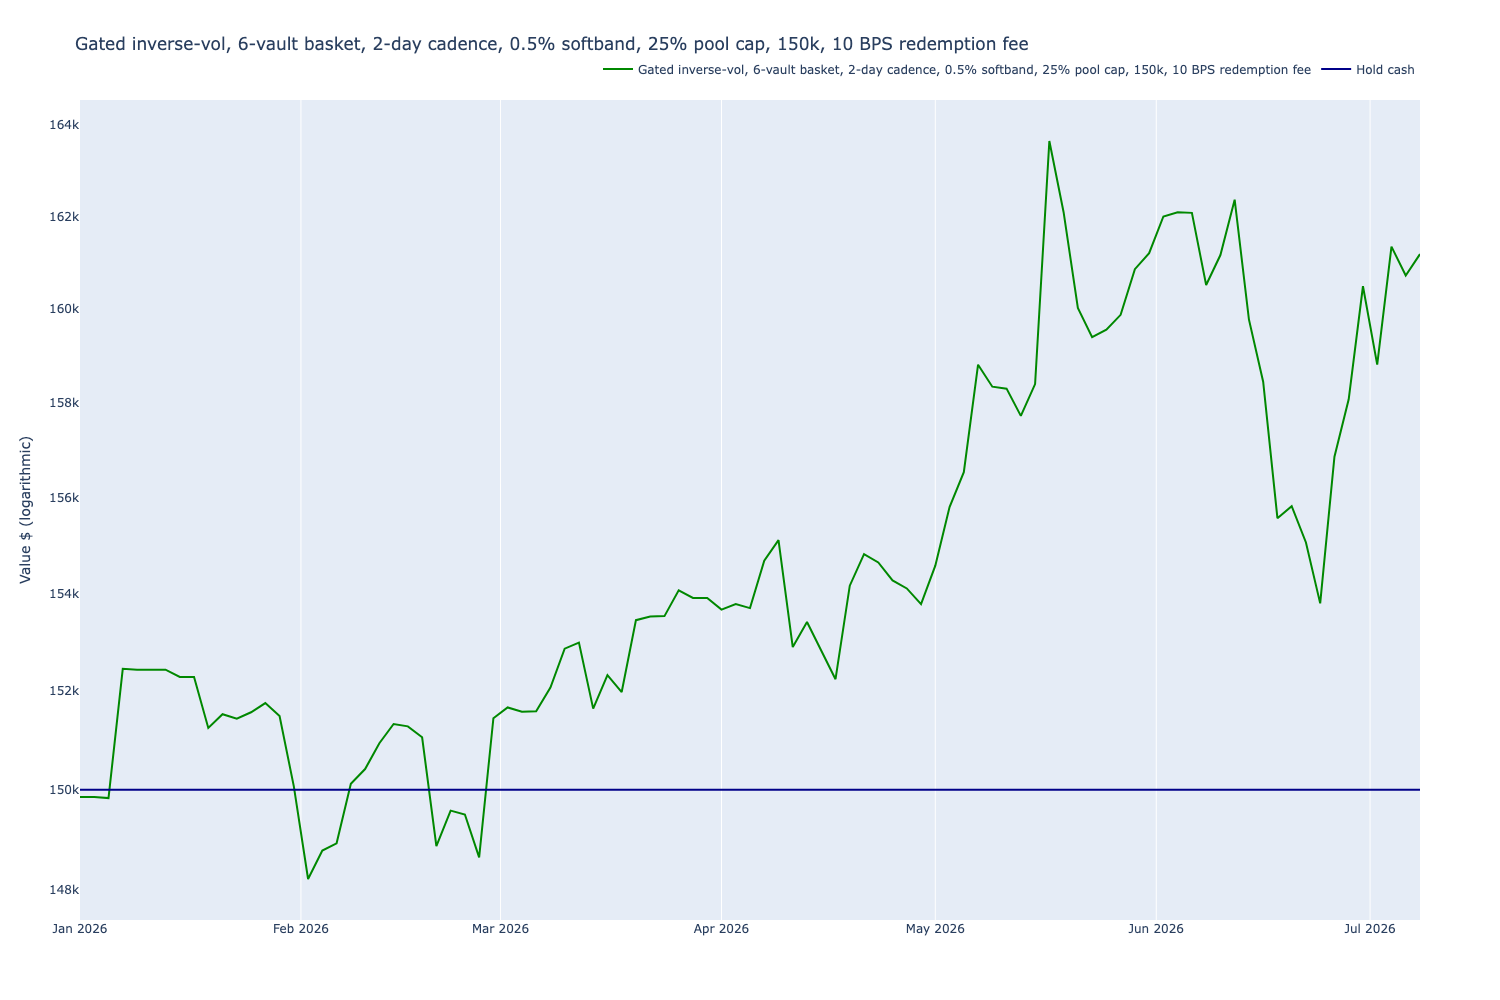

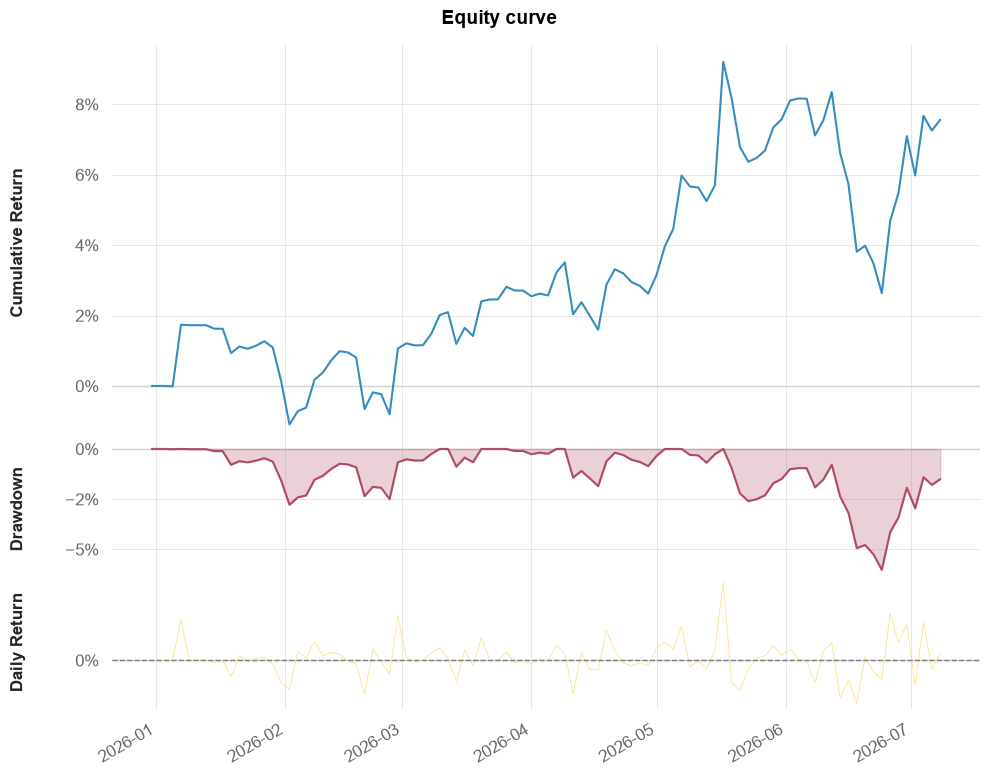

In [11]:
fig = chart_renderer.render(equity_curve_with_benchmark)
fig.show()

fig = chart_renderer.render(equity_curve_with_drawdown)
display(fig)


# Asset weights

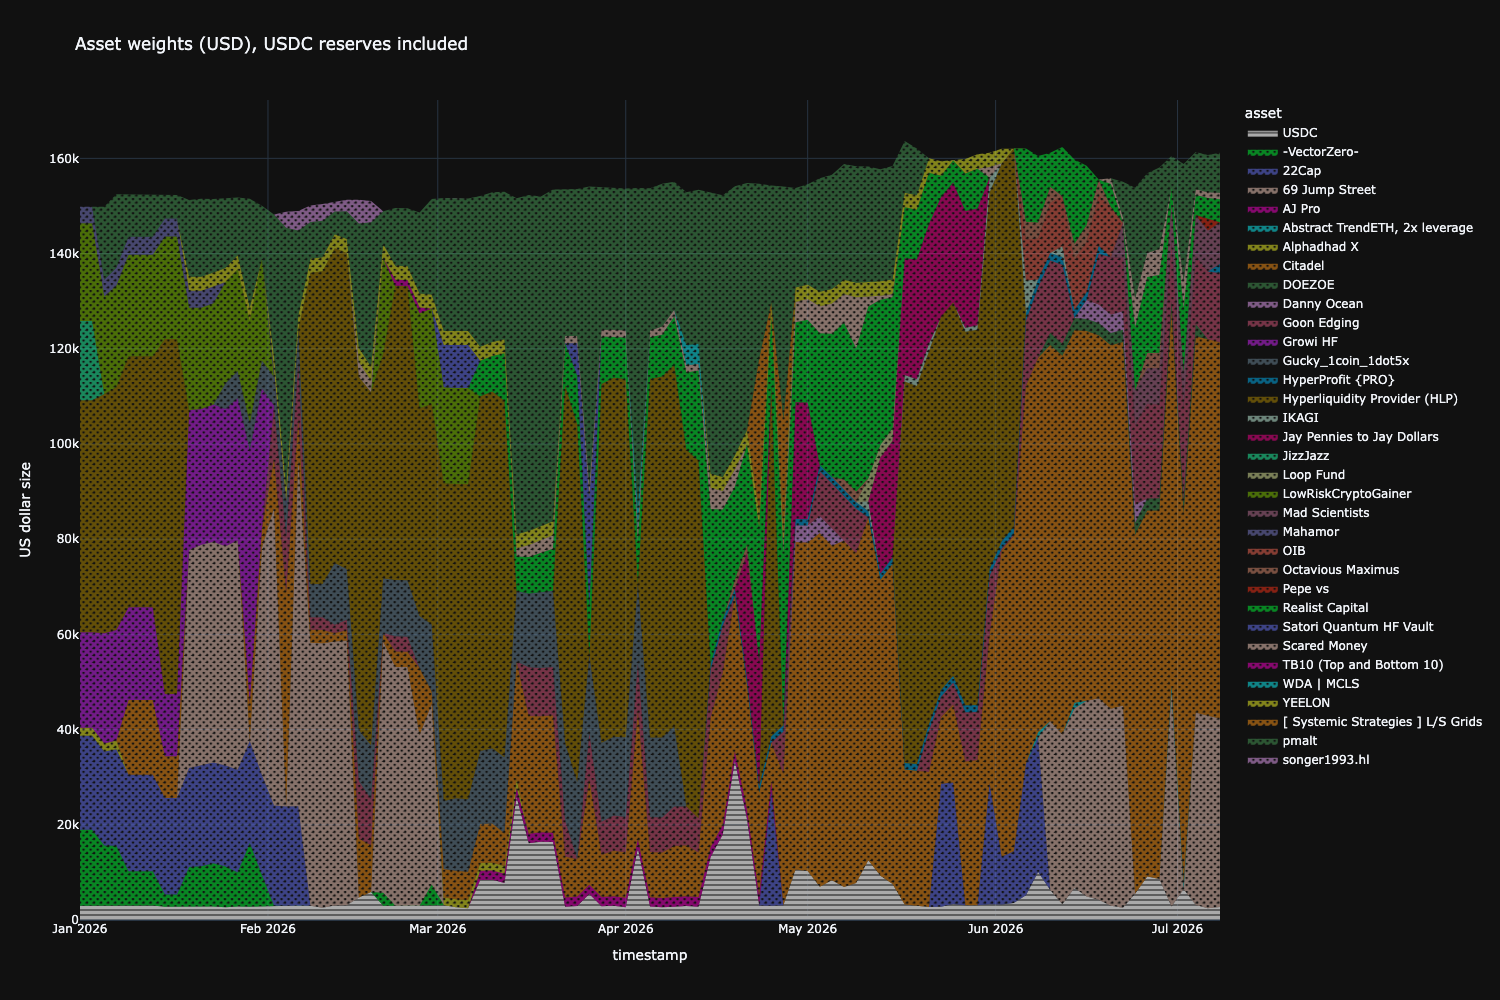

,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2026-05-17,Hyperliquidity Provider (HLP),"$80,146.84",
Min position (excluding USDC),2026-06-02,Goon Edging,$407.03,
Mean position (excluding USDC),,,"$18,765.78",
Max position (excluding USDC),2026-03-14,pmalt,56.11%,
Min position (excluding USDC),2026-06-02,Goon Edging,0.26%,
Mean position (excluding USDC),,,12.60%,
Max position (including USDC),2026-06-22,Citadel,49.24%,
Min position (including USDC),2026-06-02,Goon Edging,0.25%,
Mean position (including USDC),,,11.19%,


In [12]:
from tradeexecutor.utils.notebook import display_dataframe_with_html

fig = chart_renderer.render(equity_curve_by_asset)
display(fig)

display_dataframe_with_html(chart_renderer.render(weight_allocation_statistics))


# Monthly returns

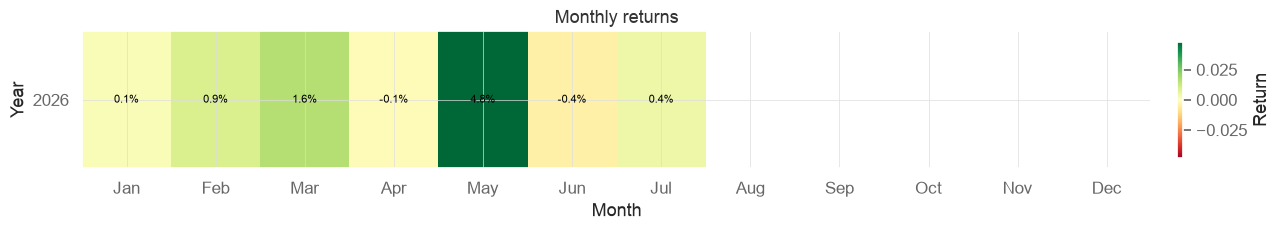

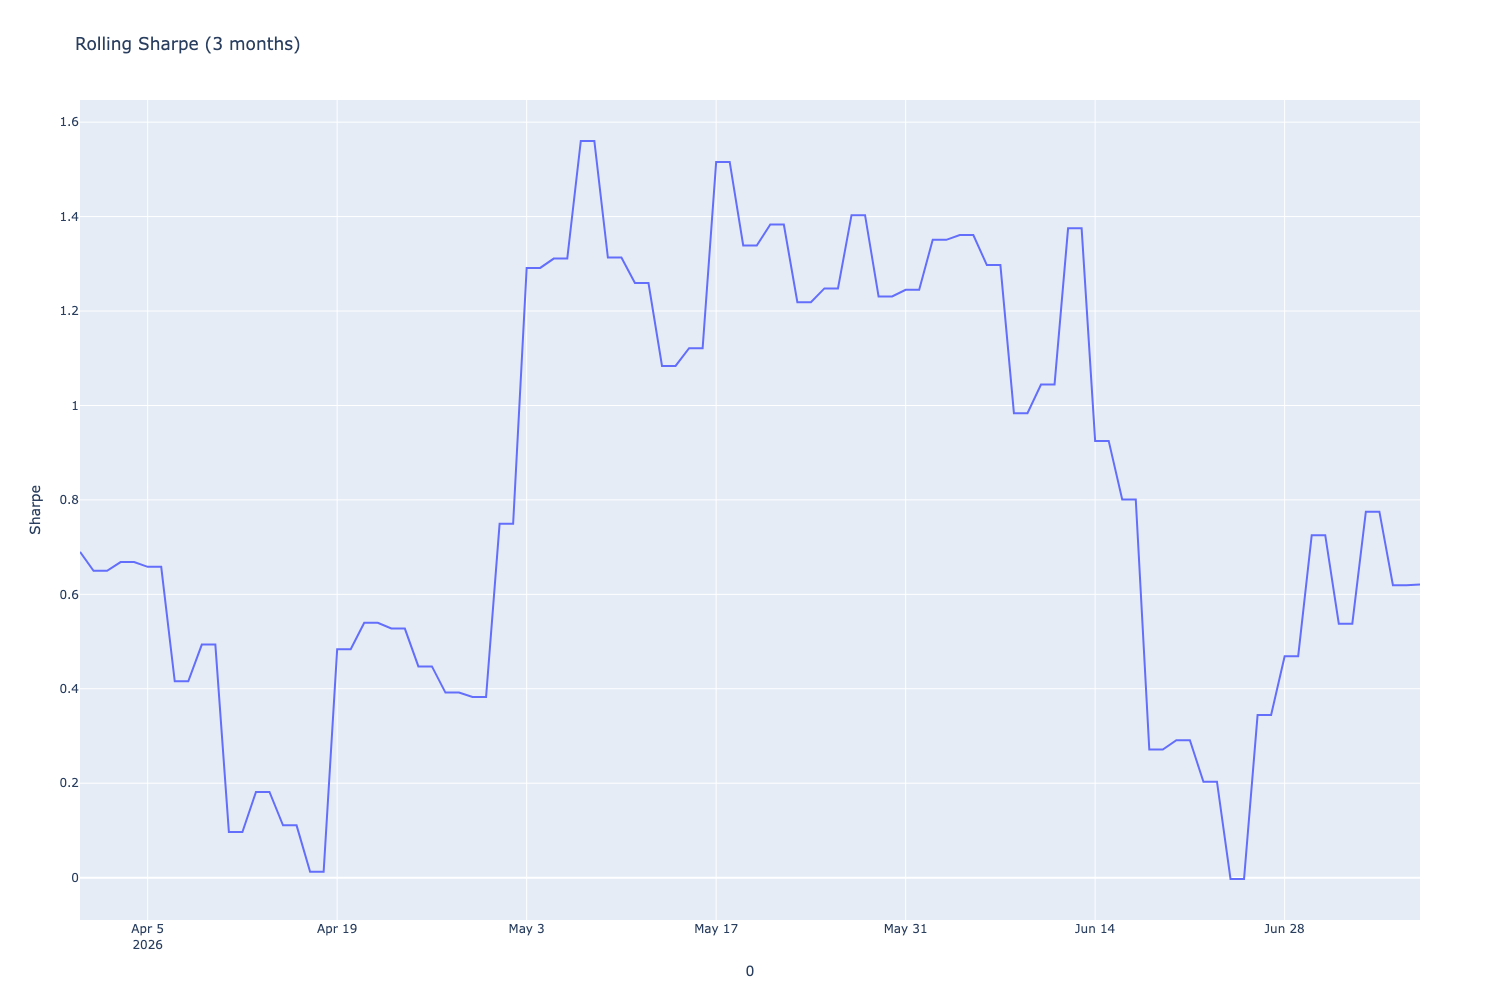

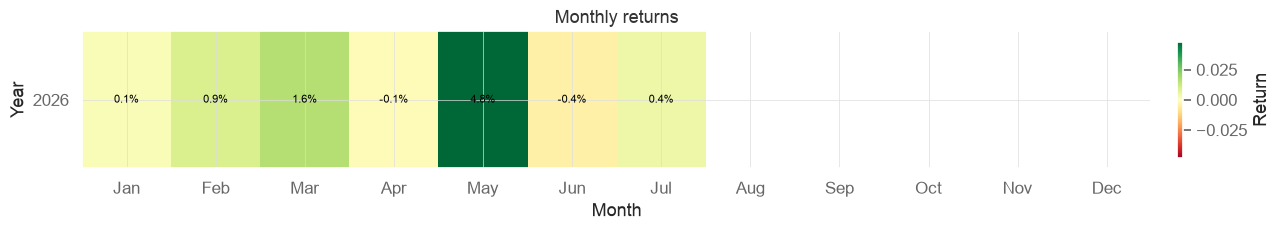

In [13]:
from tradeexecutor.visual.equity_curve import visualise_returns_over_time, calculate_rolling_sharpe
import plotly.express as px

display(visualise_returns_over_time(returns))

rolling_sharpe = calculate_rolling_sharpe(returns, freq="D", periods=90)
fig = px.line(rolling_sharpe, title="Rolling Sharpe (3 months)")
fig.update_layout(showlegend=False); fig.update_yaxes(title="Sharpe")
fig.show()


# Benchmark comparison and positions

In [14]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

display(compare_strategy_backtest_to_multiple_assets(state, strategy_universe, display=False, asset_count=2))

profit_by_position = sorted(
    ((p.get_realised_profit_usd() or 0.0, p) for p in positions),
    key=lambda x: x[0], reverse=True,
)
def pos_rows(items):
    return pd.DataFrame([{ 'Profit USD': pnl, 'Pair': p.pair.base.token_symbol,
        'Opened': p.opened_at, 'Closed': p.closed_at, 'Trades': len(p.trades) } for pnl, p in items])
print("Top 10 positions by profit:")
display(pos_rows(profit_by_position[:10]))
print("Biggest 8 losers:")
display(pos_rows(sorted(profit_by_position, key=lambda x: x[0])[:8]))

display(chart_renderer.render(positions_at_end))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0,0,0
Time in Market,0.48,0.98,0.98
Cumulative Return,0.08,-0.32,-0.45
CAGR﹪,0.15,-0.52,-0.68
Sharpe,1.38,-1.28,-1.43
Prob. Sharpe Ratio,0.85,0.18,0.15
Smart Sharpe,1.37,-1.27,-1.42
Sortino,2.29,-1.72,-1.93


Top 10 positions by profit:


,Profit USD,Pair,Opened,Closed,Trades
0,7651.892085,pmalt,2026-01-05,2026-05-21,48
1,4036.062876,Realist Ca,2026-03-08,2026-05-31,34
2,3894.666320,Scared Mon,2026-04-27,2026-05-17,8
3,3003.335540,Realist Ca,2026-06-24,NaT,6
4,1915.940061,Goon Edgin,2026-02-02,2026-02-20,10
5,1614.456567,Goon Edgin,2026-06-18,NaT,11
6,730.650964,69 Jump St,2026-02-06,2026-02-16,4
7,720.129476,Goon Edgin,2026-05-21,2026-06-14,10
8,679.218053,Scared Mon,2026-07-02,NaT,3
9,662.097682,69 Jump St,2026-02-20,2026-03-02,5


Biggest 8 losers:


,Profit USD,Pair,Opened,Closed,Trades
0,-3102.371690,Realist Ca,2026-06-06,2026-06-18,7
1,-1861.418404,songer1993,2026-02-04,2026-02-20,7
2,-1746.586978,IKAGI,2026-06-06,2026-06-08,2
3,-1566.708855,-VectorZer,2026-01-01,2026-02-02,12
4,-1372.100505,Citadel,2026-01-09,2026-01-19,3
5,-1083.764456,[ Systemic,2026-04-23,2026-04-25,2
6,-956.949433,Citadel,2026-01-29,NaT,69
7,-764.381921,Scared Mon,2026-02-16,2026-02-20,2


,token,value,vault,protocol,link
position_id,,,,,
14,Citadel,79077.945202,Citadel,hyperliquid,0xda51323fe9800c8365646ad5c7ade0dd17fdc167
79,Goon Edgin,14536.138323,Goon Edging,hyperliquid,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f
82,Mad Scient,8801.130915,Mad Scientists,hyperliquid,0x565b1c32936bdaa526947178acc95c5b08cfacc4
83,pmalt,8420.543987,pmalt,hyperliquid,0x4dec0a851849056e259128464ef28ce78afa27f6
84,Realist Ca,4810.035710,Realist Capital,hyperliquid,0x77fee2df7bad4f1db93052fa82bf78eaab771a16
88,Scared Mon,1363.034467,Scared Money,hyperliquid,0x5290ab34acb59cfe1371baa5782eba14433d308f
89,69 Jump St,39597.193555,69 Jump Street,hyperliquid,0xa844d7ac9fa3424c4fd38a25baa23e460ec3e802
91,HyperProfi,1862.551803,HyperProfit {PRO},hyperliquid,0xc22db2c04e054786426671cec0b766c07304fb20


# Cash deployment diagnostics

Why does the strategy hold cash? Per cycle, the allocator redistributes equity a capped
position cannot take to the *remaining selected* signals, but it hard-stops at
`max_assets_in_portfolio` positions — so once all selected vaults hit their caps
(`per_position_cap_of_pool_pct` x vault TVL, or `max_concentration_pct` x investable equity),
the remainder is stranded as cash. This section quantifies which cap binds and how much
cash it strands, parsed from the per-cycle diagnostics messages.


,value
cycles,95.00
mean cash %,4.73
median cash %,2.01
max cash %,100.00
final-cycle cash %,1.54
mean deployment shortfall % of investable,1.63
cycles with shortfall > 10% of investable,4.00
mean signals pool-capped per cycle,3.91
mean signals concentration-capped per cycle,1.41
cycles where ALL selected signals were pool-capped,0.00


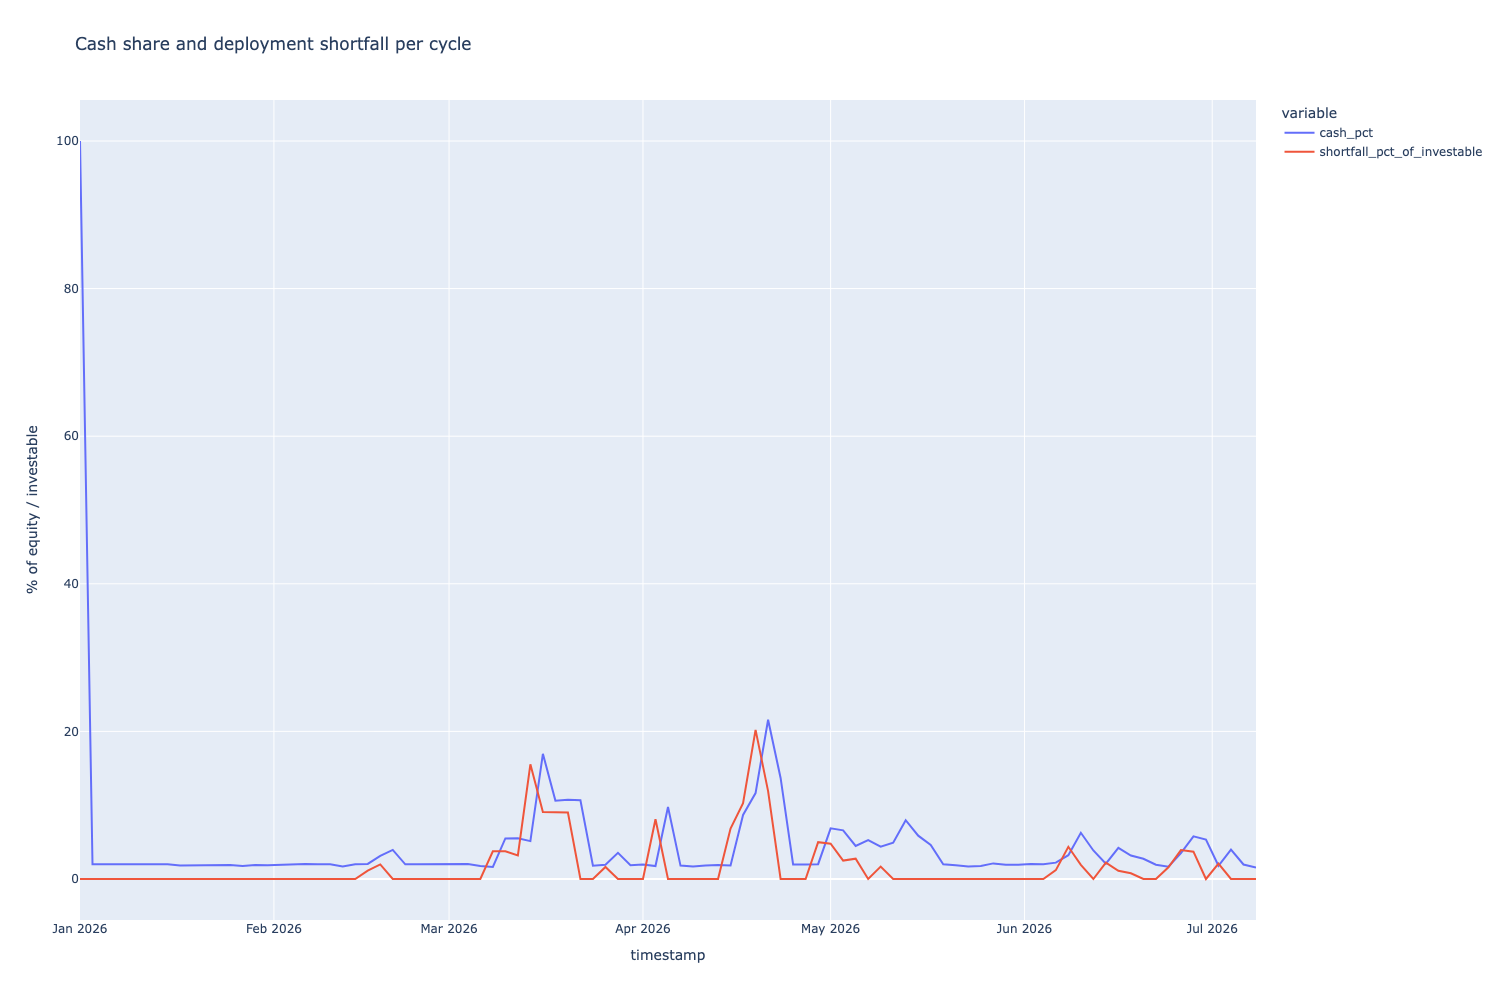

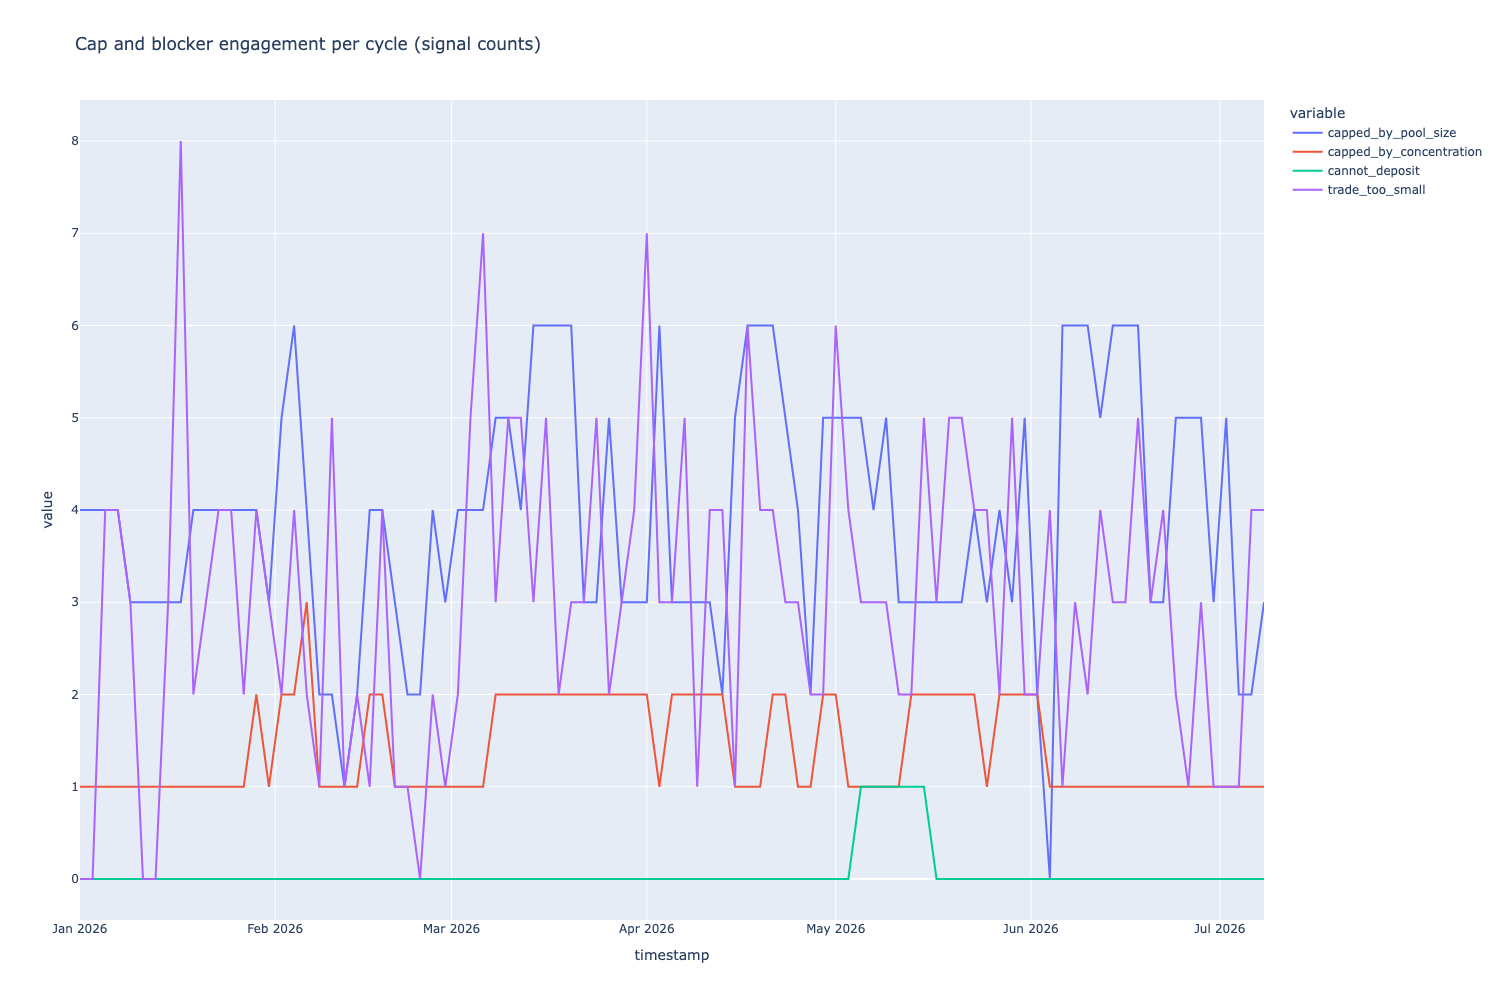

Last 30 cycles:


,cash_pct,cannot_deposit,deposit_window_skips,capped_by_pool_size,top_signal_pair
timestamp,,,,,
2026-05-11,4.9,1,1,3,YEELON-USDC
2026-05-13,8.0,1,1,3,YEELON-USDC
2026-05-15,5.9,1,1,3,YEELON-USDC
2026-05-17,4.6,0,2,3,YEELON-USDC
2026-05-19,2.0,0,2,3,YEELON-USDC
2026-05-21,1.9,0,2,3,YEELON-USDC
2026-05-23,1.7,0,2,4,YEELON-USDC
2026-05-25,1.8,0,2,3,Hyperliqui-USDC
2026-05-27,2.1,0,2,4,YEELON-USDC


In [15]:
import re

import plotly.express as px


def extract_allocation_df(state) -> pd.DataFrame:
    """Parse per-cycle equity/cash/allocation and cap-flag counts from diagnostics messages."""
    rows = []
    for unix_ts, messages in sorted(state.visualisation.messages.items(), key=lambda item: item[0]):
        if not messages:
            continue
        message = '\n'.join(messages)

        def _usd(label):
            match = re.search(rf'{re.escape(label)}: ([0-9,.\-]+) USD', message)
            return float(match.group(1).replace(',', '')) if match else float('nan')

        def _count(label):
            match = re.search(rf'{re.escape(label)}: ([0-9]+)', message)
            return int(match.group(1)) if match else 0

        rows.append({
            'timestamp': datetime.datetime.fromtimestamp(unix_ts, datetime.timezone.utc).replace(tzinfo=None),
            'total_equity': _usd('Total equity'),
            'cash': _usd('Cash'),
            'investable': _usd('Investable equity'),
            'accepted': _usd('Accepted investable equity'),
            'discarded_liquidity': _usd('Discarded allocation because of lack of lit liquidity'),
            'candidates': _count('Candidate signals created'),
            'selected': _count('Selected survivor signals'),
            'capped_by_pool_size': _count('Signals with flag capped_by_pool_size'),
            'capped_by_concentration': _count('Signals with flag capped_by_concentration'),
            'cannot_deposit': _count('Signals with flag cannot_deposit'),
            'deposit_window_skips': _count('Candidates skipped for closed deposit window'),
            'trade_too_small': _count('Signals with flag individual_trade_size_too_small'),
            'top_signal_pair': (re.search(r'Top signal pair: (\S+)', message).group(1)
                                if re.search(r'Top signal pair: (\S+)', message) else None),
        })
    return pd.DataFrame(rows).set_index('timestamp')


alloc_df = extract_allocation_df(state)
alloc_df['cash_pct'] = alloc_df['cash'] / alloc_df['total_equity'] * 100
alloc_df['deployment_shortfall'] = alloc_df['investable'] - alloc_df['accepted']
alloc_df['shortfall_pct_of_investable'] = alloc_df['deployment_shortfall'] / alloc_df['investable'] * 100

deployment_summary = pd.Series({
    'cycles': len(alloc_df),
    'mean cash %': alloc_df['cash_pct'].mean(),
    'median cash %': alloc_df['cash_pct'].median(),
    'max cash %': alloc_df['cash_pct'].max(),
    'final-cycle cash %': alloc_df['cash_pct'].iloc[-1],
    'mean deployment shortfall % of investable': alloc_df['shortfall_pct_of_investable'].mean(),
    'cycles with shortfall > 10% of investable': int((alloc_df['shortfall_pct_of_investable'] > 10).sum()),
    'mean signals pool-capped per cycle': alloc_df['capped_by_pool_size'].mean(),
    'mean signals concentration-capped per cycle': alloc_df['capped_by_concentration'].mean(),
    'cycles where ALL selected signals were pool-capped': int(
        ((alloc_df['capped_by_pool_size'] >= alloc_df['selected']) & (alloc_df['selected'] > 0)).sum()
    ),
    'cycles with < 5 gated candidates': int((alloc_df['candidates'] < int(Parameters.max_assets_in_portfolio)).sum()),
    'cycles with a cannot_deposit signal (closed deposit window)': int((alloc_df['cannot_deposit'] > 0).sum()),
    'cycles skipping closed-window candidates at selection': int((alloc_df['deposit_window_skips'] > 0).sum()),
    'total closed-window candidates skipped at selection': int(alloc_df['deposit_window_skips'].sum()),
    'mean cash % when cannot_deposit engaged': alloc_df.loc[alloc_df['cannot_deposit'] > 0, 'cash_pct'].mean(),
    'mean cash % when no cannot_deposit': alloc_df.loc[alloc_df['cannot_deposit'] == 0, 'cash_pct'].mean(),
}, name='value')
display(deployment_summary.to_frame().round(2))

fig = px.line(alloc_df[['cash_pct', 'shortfall_pct_of_investable']], title='Cash share and deployment shortfall per cycle')
fig.update_yaxes(title='% of equity / investable')
fig.show()

fig = px.line(alloc_df[['capped_by_pool_size', 'capped_by_concentration', 'cannot_deposit', 'trade_too_small']], title='Cap and blocker engagement per cycle (signal counts)')
fig.show()

print('Last 30 cycles:')
display(alloc_df[['cash_pct', 'cannot_deposit', 'deposit_window_skips', 'capped_by_pool_size', 'top_signal_pair']].tail(30).round(1))


In [16]:
# Shared analysis helpers used by every grid in this notebook.
#
# Kept in their own cell deliberately: earlier variants defined these inside a grid cell, and
# replacing that grid in the next variant silently removed them.
from tradeexecutor.analysis.weights import calculate_asset_weights, visualise_weights


def deployment_stats(state_) -> dict:
    """Cash, deployment shortfall and cap-binding counts for one run.

    `extract_allocation_df()` returns the raw per-cycle fields; `cash_pct` and the shortfall
    percentage are derived from them above rather than inside that function, so recompute here.
    """
    alloc = extract_allocation_df(state_)
    if not len(alloc):
        return {}
    cash_pct = alloc["cash"] / alloc["total_equity"] * 100
    shortfall_pct = (alloc["investable"] - alloc["accepted"]) / alloc["investable"] * 100
    return {
        "Mean cash %": float(cash_pct.mean()),
        "Deployment shortfall %": float(shortfall_pct.mean()),
        "Cycles >10% unplaced": int((shortfall_pct > 10).sum()),
        "Pool-capped per cycle": float(alloc["capped_by_pool_size"].mean()),
        "Concentration-capped per cycle": float(alloc["capped_by_concentration"].mean()),
    }


def weight_concentration_stats(weights_series: pd.Series) -> dict:
    """Largest weight and effective position count from an asset weight timeline.

    `calculate_asset_weights()` returns a (timestamp, asset) MultiIndex of USD values, so normalise
    within each timestamp before measuring concentration. Reserves are dropped: cash is not a
    position and would flatter the diversification measure exactly when the strategy fails to
    deploy.
    """
    frame = weights_series.unstack(level=1).fillna(0.0)
    for reserve in ("USDC", "USDT", "USDC.e", "USDT0"):
        if reserve in frame.columns:
            frame = frame.drop(columns=[reserve])
    totals = frame.sum(axis=1)
    frame = frame.loc[totals > 0]
    if not len(frame):
        return {}
    normalised = frame.div(frame.sum(axis=1), axis=0)
    herfindahl = (normalised ** 2).sum(axis=1)
    return {
        "Mean largest weight": float(normalised.max(axis=1).mean()),
        "Max largest weight": float(normalised.max(axis=1).max()),
        "Effective positions": float((1.0 / herfindahl).mean()),
        "Mean held": float((normalised > 0.005).sum(axis=1).mean()),
    }


## End-of-backtest drill-down

The held vaults at the end, their TVL, and the pool cap each one imposes. If the sum of
pool caps is below investable equity, the cash pile is structural: the five selected
vaults simply cannot absorb the bankroll at a 15% TVL share.


In [17]:
final_rows = []
for position in state.portfolio.open_positions.values():
    pair = position.pair
    try:
        tvl_series = indicator_data.get_indicator_series('tvl', pair=pair)
        last_tvl = float(tvl_series.dropna().iloc[-1])
    except Exception:
        last_tvl = float('nan')
    final_rows.append({
        'Vault': pair.base.token_symbol,
        'Position value USD': float(position.get_value()),
        'Vault TVL USD': last_tvl,
        'Pool cap (15% of TVL) USD': last_tvl * float(Parameters.per_position_cap_of_pool_pct),
    })
final_positions_df = pd.DataFrame(final_rows).sort_values('Position value USD', ascending=False)
display(final_positions_df.round(0))

final_cycle = alloc_df.iloc[-1]
print(f"Final cycle equity: {final_cycle['total_equity']:,.0f} USD, cash: {final_cycle['cash']:,.0f} USD ({final_cycle['cash_pct']:.1f}%)")
print(f"Investable (98% target): {final_cycle['investable']:,.0f} USD, accepted by caps: {final_cycle['accepted']:,.0f} USD")
print(f"Sum of pool caps across held vaults: {final_positions_df['Pool cap (15% of TVL) USD'].sum():,.0f} USD")

print()
print('Last cycle raw diagnostics:')
last_ts = max(state.visualisation.messages)
print('\n'.join(state.visualisation.messages[last_ts]))


,Vault,Position value USD,Vault TVL USD,Pool cap (15% of TVL) USD
0,Citadel,79078.0,558891.0,83834.0
6,69 Jump St,39597.0,258067.0,38710.0
1,Goon Edgin,14536.0,108169.0,16225.0
2,Mad Scient,8801.0,59388.0,8908.0
3,pmalt,8421.0,513987.0,77098.0
4,Realist Ca,4810.0,485292.0,72794.0
7,HyperProfi,1863.0,12266.0,1840.0
5,Scared Mon,1363.0,50278.0,7542.0


Final cycle equity: 161,184 USD, cash: 2,486 USD (1.5%)
Investable (98% target): 157,961 USD, accepted by caps: 157,961 USD
Sum of pool caps across held vaults: 306,951 USD

Last cycle raw diagnostics:
Cycle: #95
Rebalanced: 👍
Open/about to open positions: 9
Max position value change: 2,115.02 USD
Rebalance threshold: 75.00 USD
Trades decided: 5
Pairs meeting inclusion criteria: 199
Pairs meeting TVL inclusion criteria: 202
Candidate signals created: 186
Selected survivor signals: 9
Candidates skipped for closed deposit window: 2
CAGR lookback days: 360
Sharpe lookback days: 180
CAGR weight (blend): 0.5
Total equity: 161,184.27 USD
Cash: 2,485.52 USD
Redeemable capital: 158,698.75 USD
Pending redemptions: 0.00 USD
Investable equity: 157,960.58 USD
Accepted investable equity: 157,960.58 USD
Allocated to signals: 157,960.58 USD
Discarded allocation because of lack of lit liquidity: 58,493.70 USD
Rebalance volume: 0.00 USD
Top signal pair: Citadel-USDC
Top signal value: 298634.9124678297


# Redemption fee verification and cost accounting

Verify the fee actually reached the executed sell prices, and total up what it cost.

Two sell paths exist and both must be checked:

- **Full closes** go through `PositionManager.close_position()`, which prices straight off
  `BacktestPricing.get_sell_price()`, so the fee lands as `share price x (1 - fee)`.
- **Partial reductions** of a Hypercore position go through `PositionManager.adjust_position()`,
  which overrides the pricing-model price with the position's *marked* price
  (trade-executor `7e673dc6`, so live partial redemptions size off the live implied share price).
  That marked price is itself produced by `BacktestValuationModel` from `get_sell_price()` at the
  same cycle timestamp, so the fee is still charged — but the trade's `planned_mid_price` is
  overwritten with the same value and can no longer be used to measure it.

The verification below is therefore independent of both paths: it compares each executed sell
price against the vault's own daily close (share price) at the time the trade was planned.


,Trades,Configured fee,Median implied fee,Mean implied fee,Within 1 BPS of configured
Sell type,,,,,
Full close,81,0.100%,0.100%,-0.434%,50.6%
Partial reduction,134,0.100%,0.100%,-0.116%,62.7%
All sells,215,0.100%,0.100%,-0.236%,58.1%


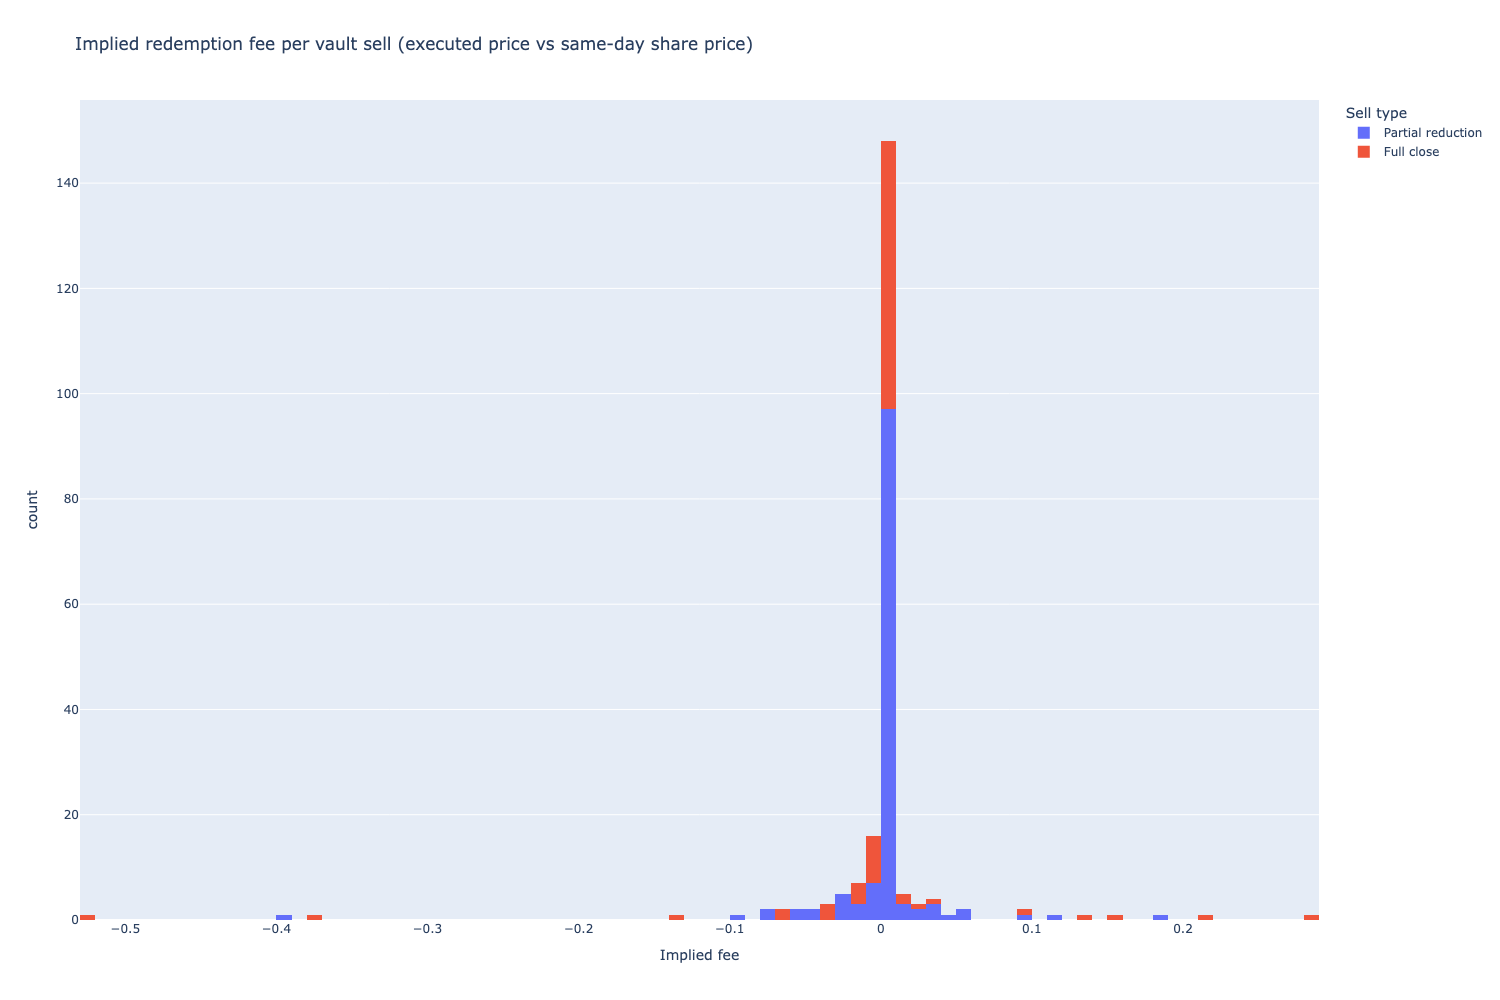

,Vault sell trades,Redemption volume USD,Redemption fee paid USD,Fee as % of initial capital,Fee as % of final equity,Redemption turnover x initial capital
0,215,"$2,356,608","$2,359",1.57%,1.46%,15.7x


,Sells,Proceeds USD,Fee paid USD
Vault,,,
Hyperliqui,13,"$577,300",$577.88
pmalt,30,"$340,361",$340.70
69 Jump St,13,"$329,056",$329.39
Citadel,30,"$236,309",$236.55
Realist Ca,19,"$149,308",$149.46
Goon Edgin,22,"$119,013",$119.13
22Cap,6,"$115,067",$115.18
Jay Pennie,4,"$76,017",$76.09
Growi HF,6,"$63,801",$63.87


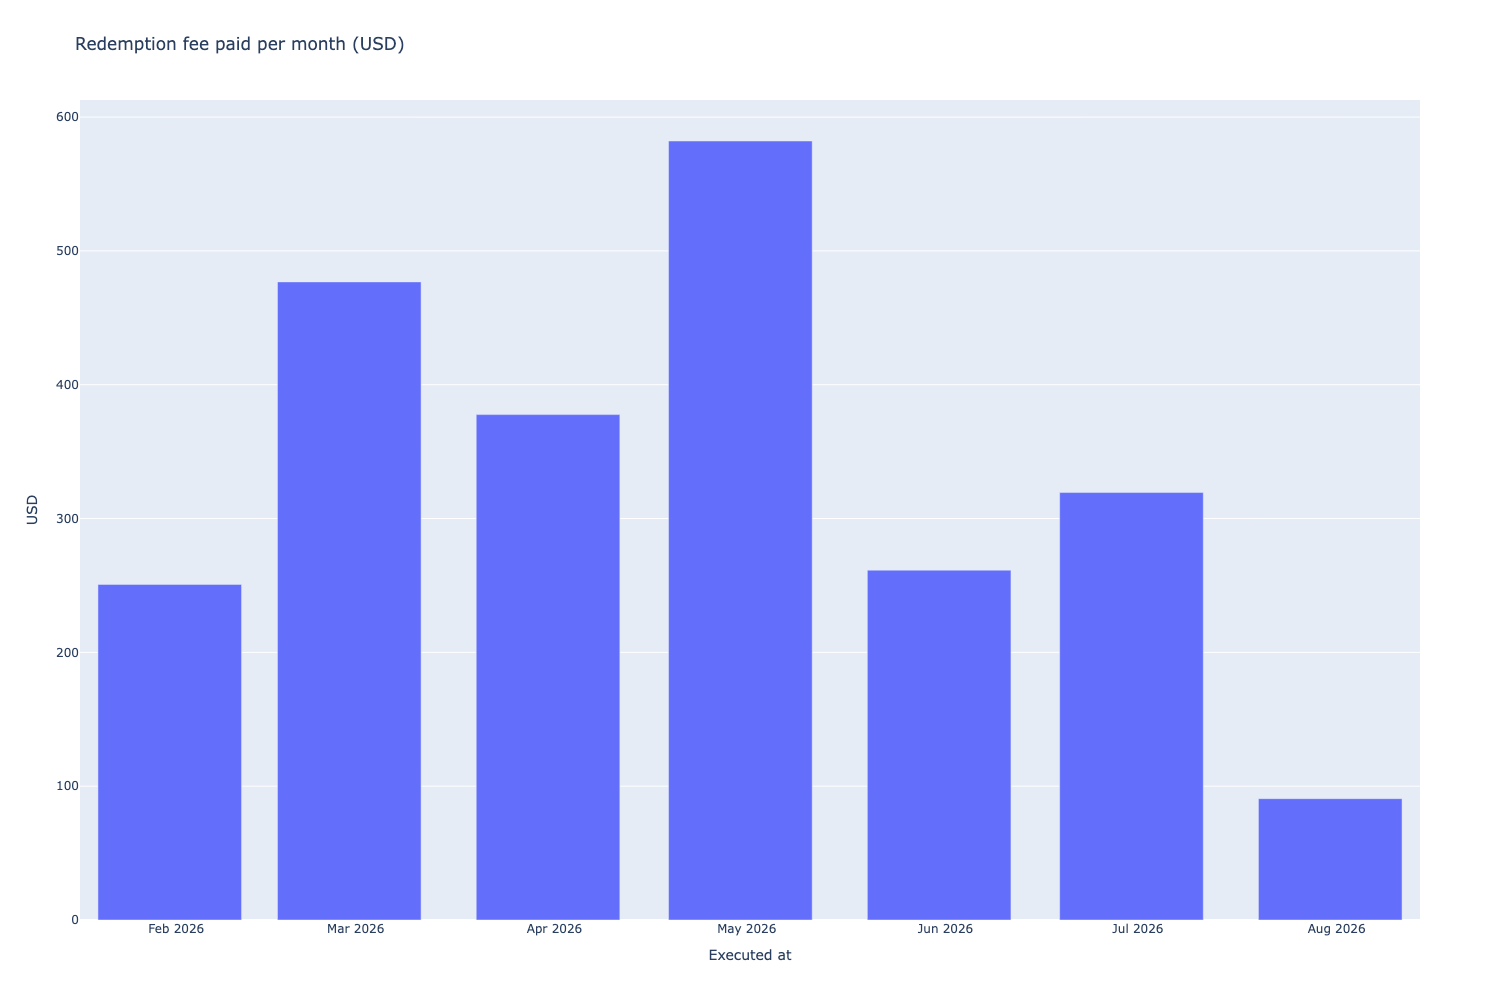

In [18]:
vault_close_cache = {}


def get_vault_share_price(pair, ts) -> float:
    """Vault share price (daily close) as of ``ts``, straight from the candle data."""
    closes = vault_close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        closes = candles.set_index('timestamp')['close'].sort_index()
        vault_close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float('nan')


def build_vault_sell_df(state_, fee_: float) -> pd.DataFrame:
    """Every successful vault sell, with the fee implied by its executed price.

    :param fee_:
        Redemption fee configured for the run that produced ``state_``.
    """
    rows = []
    for trade in state_.portfolio.get_all_trades():
        if not trade.pair.is_vault():
            continue
        if not trade.is_sell() or not trade.is_success():
            continue
        share_price = get_vault_share_price(trade.pair, trade.opened_at)
        proceeds = abs(float(trade.executed_reserve or 0.0))
        rows.append({
            'Vault': trade.pair.base.token_symbol,
            'Planned at': trade.opened_at,
            'Executed at': trade.executed_at,
            'Sell type': 'Full close' if trade.closing else 'Partial reduction',
            'Share price': share_price,
            'Planned price': float(trade.planned_price),
            'Implied fee': float(1.0 - trade.planned_price / share_price) if share_price == share_price else float('nan'),
            'Proceeds USD': proceeds,
            'Fee paid USD': proceeds * fee_ / (1.0 - fee_) if fee_ else 0.0,
        })
    return pd.DataFrame(rows)


def summarise_implied_fees(df: pd.DataFrame, fee_: float) -> pd.DataFrame:
    """Implied-fee statistics, split by sell type."""
    rows = []
    for sell_type, group in list(df.groupby('Sell type')) + [('All sells', df)]:
        implied = group['Implied fee'].dropna()
        rows.append({
            'Sell type': sell_type,
            'Trades': len(group),
            'Configured fee': fee_,
            'Median implied fee': float(implied.median()),
            'Mean implied fee': float(implied.mean()),
            'Within 1 BPS of configured': float((implied.sub(fee_).abs() <= 0.0001).mean()),
        })
    return pd.DataFrame(rows).set_index('Sell type')


fee = Parameters.vault_redemption_fee
vault_sell_df = build_vault_sell_df(state, fee)

display(
    summarise_implied_fees(vault_sell_df, fee).style.format({
        'Configured fee': '{:.3%}',
        'Median implied fee': '{:.3%}',
        'Mean implied fee': '{:.3%}',
        'Within 1 BPS of configured': '{:.1%}',
    }).set_caption('Implied redemption fee by sell type')
)

fig = px.histogram(
    vault_sell_df,
    x='Implied fee',
    color='Sell type',
    nbins=120,
    title='Implied redemption fee per vault sell (executed price vs same-day share price)',
)
fig.show()

total_fee_usd = float(vault_sell_df['Fee paid USD'].sum())
total_proceeds_usd = float(vault_sell_df['Proceeds USD'].sum())
final_equity = float(equity.iloc[-1])

fee_summary_df = pd.DataFrame([{
    'Vault sell trades': len(vault_sell_df),
    'Redemption volume USD': total_proceeds_usd,
    'Redemption fee paid USD': total_fee_usd,
    'Fee as % of initial capital': total_fee_usd / Parameters.initial_cash,
    'Fee as % of final equity': total_fee_usd / final_equity,
    'Redemption turnover x initial capital': total_proceeds_usd / Parameters.initial_cash,
}])
display(fee_summary_df.style.format({
    'Redemption volume USD': '${:,.0f}',
    'Redemption fee paid USD': '${:,.0f}',
    'Fee as % of initial capital': '{:.2%}',
    'Fee as % of final equity': '{:.2%}',
    'Redemption turnover x initial capital': '{:.1f}x',
}))

fee_by_vault_df = vault_sell_df.groupby('Vault').agg(
    **{
        'Sells': ('Proceeds USD', 'size'),
        'Proceeds USD': ('Proceeds USD', 'sum'),
        'Fee paid USD': ('Fee paid USD', 'sum'),
    }
).sort_values('Fee paid USD', ascending=False)
display(
    fee_by_vault_df.head(15).style.format({
        'Proceeds USD': '${:,.0f}',
        'Fee paid USD': '${:,.2f}',
    }).set_caption('Redemption fee paid by vault (top 15)')
)

monthly_fee = vault_sell_df.set_index('Executed at')['Fee paid USD'].resample('1ME').sum()
fig = px.bar(monthly_fee, title='Redemption fee paid per month (USD)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='USD')
fig.show()


# A/B against the same run without the redemption fee

The honest way to price the fee is to re-run the identical strategy on the identical universe
with the fee switched off, rather than to compare against NB53's committed numbers (vault data
is refreshed between runs, so those numbers drift for reasons unrelated to the fee).

The only difference between the two runs below is the vault sell-side fee.


In [19]:
# Same universe, same indicators, same decide_trades - only the redemption fee differs.
apply_vault_redemption_fee(strategy_universe, 0.0)

baseline_result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, 2-day cadence, 0.5% softband, 25% pool cap, 150k, no redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)

# Restore the configured fee so the rest of the notebook sees the fee-charging universe.
apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

baseline_state = baseline_result.state
baseline_equity = calculate_equity_curve(baseline_state)
baseline_returns = calculate_returns(baseline_equity)
baseline_positions = [p for p in baseline_state.portfolio.get_all_positions() if not p.is_credit_supply()]
print(f"Baseline (no fee) final equity: ${baseline_equity.iloc[-1]:,.0f}")
print(f"10 BPS fee       final equity: ${equity.iloc[-1]:,.0f}")


Baseline (no fee) final equity: $163,544
10 BPS fee       final equity: $161,182


,Final equity,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown,Positions,Trades
"Baseline, no redemption fee","$163,544",9.03%,18.27%,1.62,2.72,-5.93%,91,510
10 BPS redemption fee,"$161,182",7.45%,15.20%,1.38,2.29,-6.02%,91,511
Difference,"$-2,362",-1.57%,-3.08%,-0.24,-0.43,-0.08%,0,1


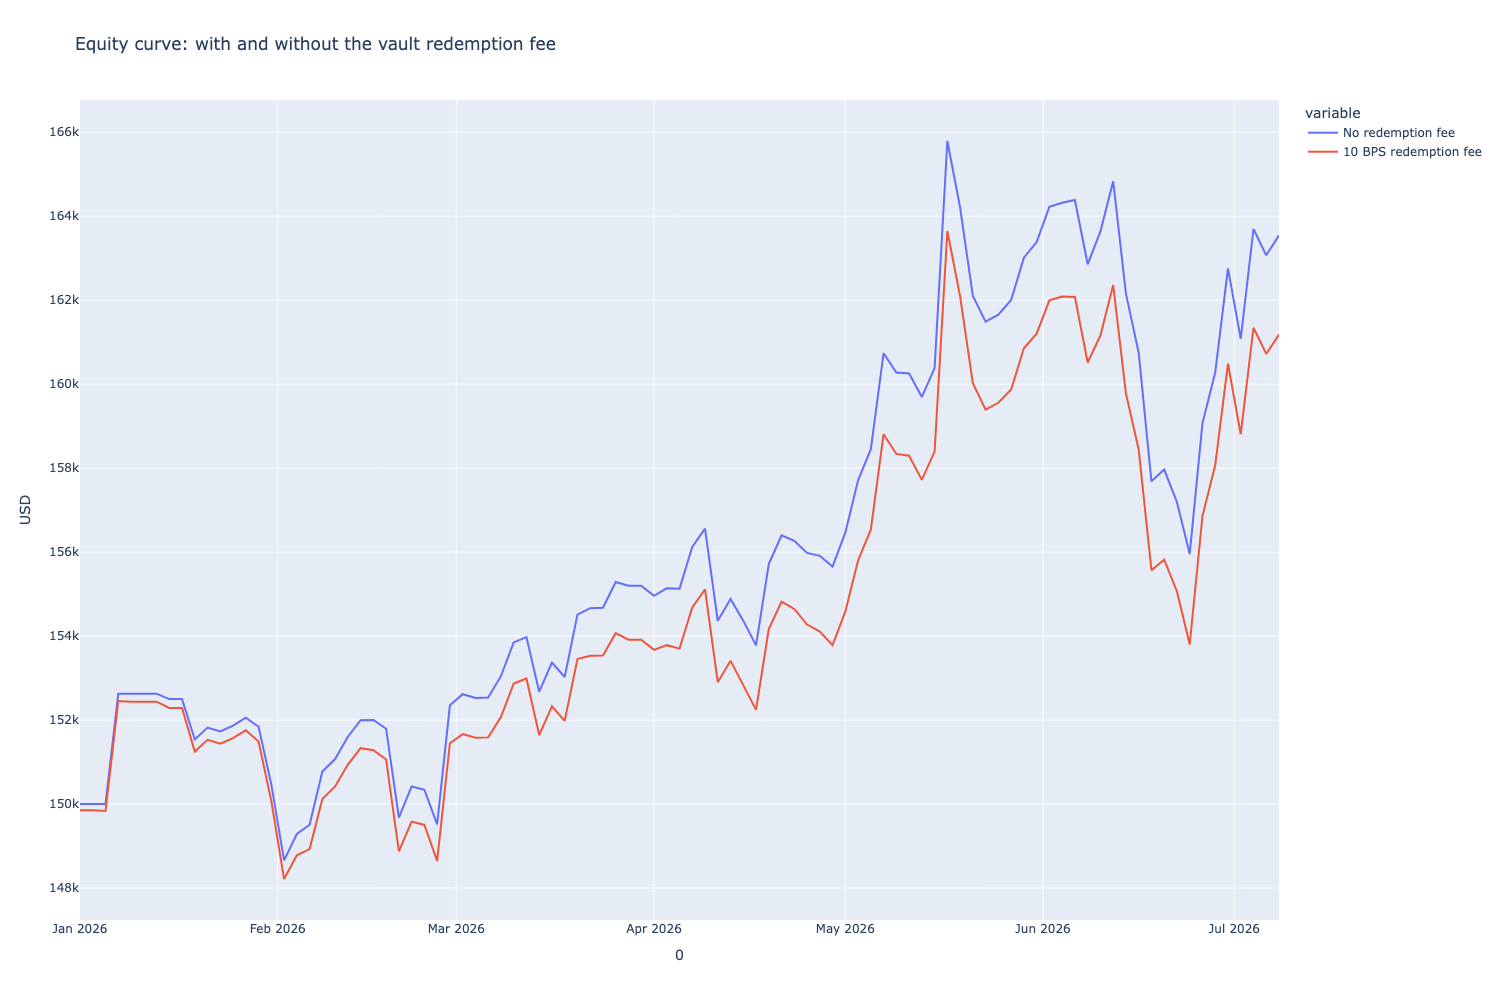

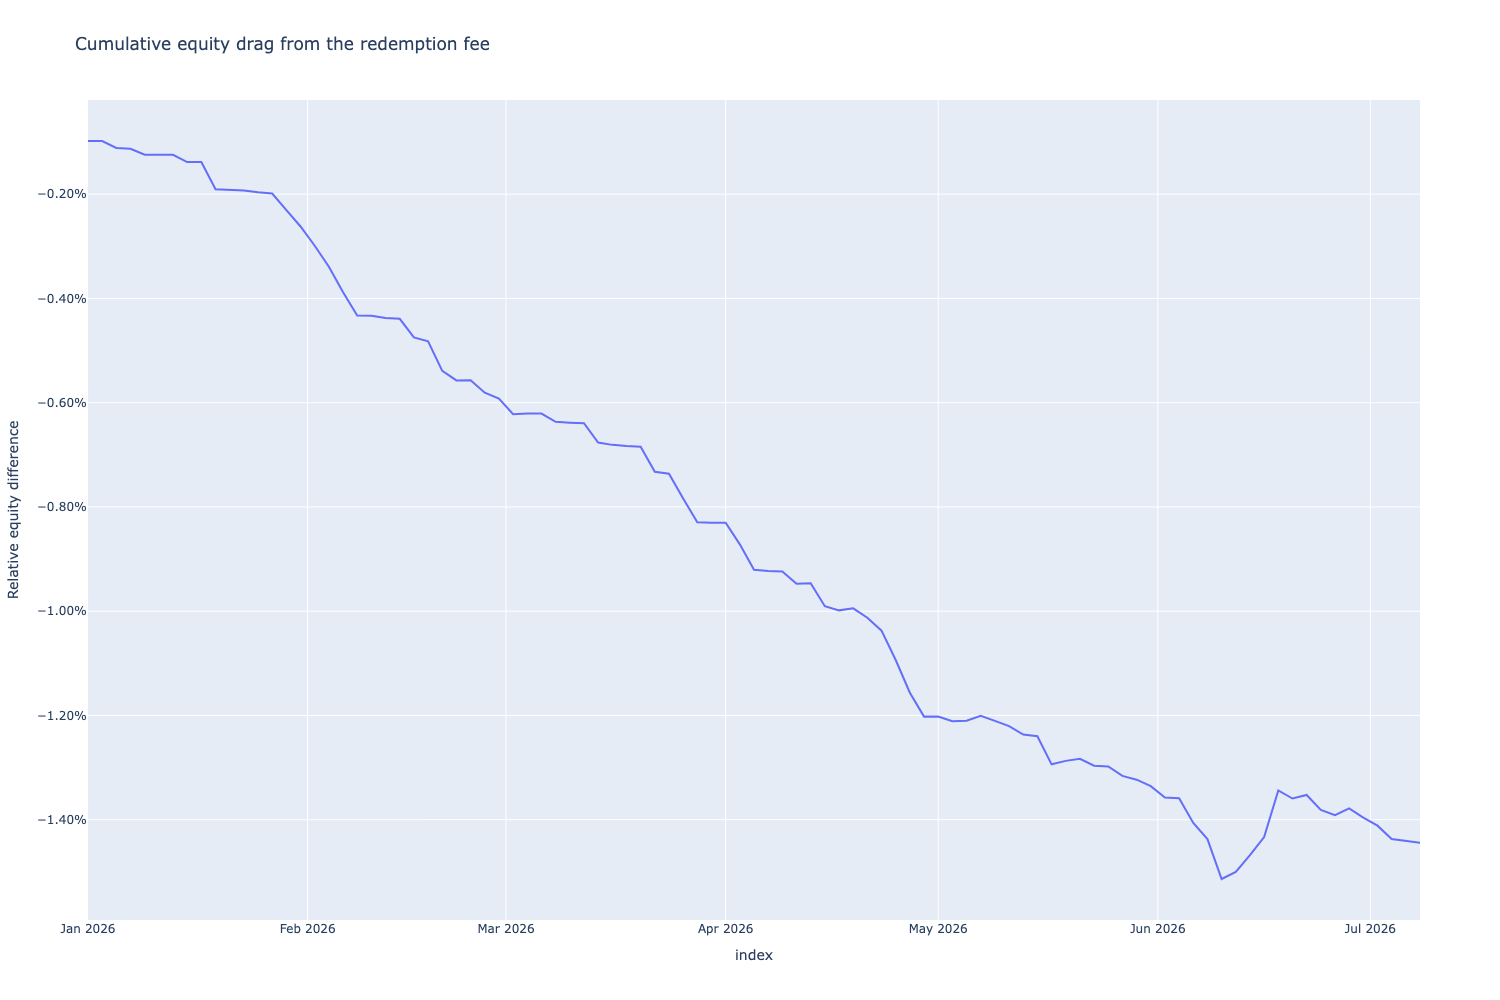

,Final equity difference USD,Final relative drag,Worst relative drag,Drag per year,Redemption fee paid USD (accounting)
0,"$-2,362",-1.44%,-1.51%,-2.80%,"$2,359"


In [20]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)


def summarise_run(label: str, equity_curve: pd.Series, state_) -> dict:
    """Headline metrics for one backtest run.

    The equity curve is sampled **once per strategy cycle**, so a 2-day cadence produces one
    observation every 48 hours. Annualising that series with ``periods=365`` would overstate its
    Sharpe and Sortino by ``sqrt(2)`` against a daily-cadence run and make the two incomparable.
    Resample onto a common daily grid first - a 2-day step becomes one non-zero day and one zero
    day, which annualises correctly and matches the basis used in the robustness cell.

    Max drawdown is still measured on whatever grid the strategy values itself: a 2-day cadence
    cannot observe a trough that opens and closes inside one of its cycles, so its drawdown is
    measured over fewer marks than a daily cadence. That is a property of the schedule, not of
    this function.
    """
    return_series = calculate_returns(equity_curve).resample("1D").sum(min_count=1).fillna(0.0).dropna()
    trades = list(state_.portfolio.get_all_trades())
    run_positions = [p for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()]
    return {
        'Run': label,
        'Final equity': float(equity_curve.iloc[-1]),
        'Cumulative return': float(equity_curve.iloc[-1] / Parameters.initial_cash - 1.0),
        'CAGR': float(calculate_cagr(return_series)),
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': float(calculate_max_drawdown(return_series)),
        'Positions': len(run_positions),
        'Trades': len(trades),
    }


comparison_df = pd.DataFrame([
    summarise_run('Baseline, no redemption fee', baseline_equity, baseline_state),
    summarise_run(f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee', equity, state),
]).set_index('Run')
delta = comparison_df.iloc[1] - comparison_df.iloc[0]
delta.name = 'Difference'
comparison_df = pd.concat([comparison_df, delta.to_frame().T])
display(comparison_df.style.format({
    'Final equity': '${:,.0f}',
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
    'Positions': '{:.0f}',
    'Trades': '{:.0f}',
}))

equity_comparison_df = pd.DataFrame({
    'No redemption fee': baseline_equity,
    f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee': equity,
}).ffill()
fig = px.line(equity_comparison_df, title='Equity curve: with and without the vault redemption fee')
fig.update_yaxes(title='USD')
fig.show()

drag = (equity_comparison_df.iloc[:, 1] / equity_comparison_df.iloc[:, 0] - 1.0)
fig = px.line(drag, title='Cumulative equity drag from the redemption fee')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='Relative equity difference', tickformat='.2%')
fig.show()

drag_df = pd.DataFrame([{
    'Final equity difference USD': float(equity.iloc[-1] - baseline_equity.iloc[-1]),
    'Final relative drag': float(drag.iloc[-1]),
    'Worst relative drag': float(drag.min()),
    'Drag per year': float(drag.iloc[-1]) / ((equity.index[-1] - equity.index[0]).days / 365.0),
    'Redemption fee paid USD (accounting)': total_fee_usd,
}])
display(drag_df.style.format({
    'Final equity difference USD': '${:,.0f}',
    'Final relative drag': '{:.2%}',
    'Worst relative drag': '{:.2%}',
    'Drag per year': '{:.2%}',
    'Redemption fee paid USD (accounting)': '${:,.0f}',
}))


In [21]:
# Control: the same implied-fee measurement on the no-fee baseline run.
#
# Hypercore partial reductions execute at the position's marked price, which is a cycle-start
# valuation and can differ from the same-day close for reasons that have nothing to do with the
# fee (stale marks, positions opened the same cycle, async settlement). The baseline run isolates
# that measurement noise: its implied fees must centre on zero, and the fee run must be the same
# distribution shifted by exactly the configured fee.
baseline_sell_df = build_vault_sell_df(baseline_state, 0.0)

control_df = pd.concat([
    summarise_implied_fees(baseline_sell_df, 0.0).assign(Run='Baseline, no fee'),
    summarise_implied_fees(vault_sell_df, Parameters.vault_redemption_fee).assign(Run='10 BPS fee'),
]).set_index('Run', append=True).reorder_levels(['Run', 'Sell type'])
display(control_df.style.format({
    'Configured fee': '{:.3%}',
    'Median implied fee': '{:.3%}',
    'Mean implied fee': '{:.3%}',
    'Within 1 BPS of configured': '{:.1%}',
}).set_caption('Implied fee measurement, fee run vs no-fee control'))

shift_df = pd.DataFrame([{
    'Median implied fee, baseline': float(baseline_sell_df['Implied fee'].median()),
    'Median implied fee, fee run': float(vault_sell_df['Implied fee'].median()),
    'Median shift': float(vault_sell_df['Implied fee'].median() - baseline_sell_df['Implied fee'].median()),
    'Mean shift': float(vault_sell_df['Implied fee'].mean() - baseline_sell_df['Implied fee'].mean()),
    'Configured fee': Parameters.vault_redemption_fee,
}])
display(shift_df.style.format('{:.3%}'))


,"Median implied fee, baseline","Median implied fee, fee run",Median shift,Mean shift,Configured fee
0,0.000%,0.100%,0.100%,0.099%,0.100%


# Diagnostic harness

`run_config()` runs one configuration through plain `run_backtest_inline` - no optimiser, no
`ignore_wallet_errors` - so a wallet failure raises instead of being suppressed, and every state is
kept for forensics. `audit_accounting()` is the standard integrity identity from NB73:

    final equity == initial cash + realised P&L + unrealised P&L - redemption fees paid

NB63/NB64 established a sound run reconciles to within ~0.3% of capital once the fee (which is not
booked into realised P&L) is added back.


In [22]:
import traceback

from tradeexecutor.backtest.backtest_execution import BacktestExecutionFailed
from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

_indicator_cache = {}


def indicators_for_lookback(lookback: int):
    """Build (or reuse) the indicator set for one volatility lookback.

    The lookback is an indicator parameter: each value needs its own indicator series, otherwise
    every configuration silently reuses the precomputed default.
    """
    lookback = int(lookback)
    if lookback not in _indicator_cache:
        lookback_parameters = StrategyParameters.from_dict(dict(parameters))
        lookback_parameters["inverse_vol_window"] = lookback
        print(f"  building indicators for a {lookback}-day lookback ...")
        _indicator_cache[lookback] = calculate_and_load_indicators_inline(
            strategy_universe=strategy_universe,
            create_indicators=indicators.create_indicators,
            parameters=lookback_parameters,
        )
    return _indicator_cache[lookback]


def run_config(label: str, overrides: dict):
    """Run one configuration deterministically, keeping the state.

    :return:
        ``(metrics_row, state, error)`` - on a wallet crash ``metrics_row`` and ``state`` are
        ``None`` and ``error`` carries the failing cycle parsed from the traceback.
    """
    apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
    run_parameters = StrategyParameters.from_dict(dict(parameters))
    for key, value in overrides.items():
        run_parameters[key] = value

    try:
        inline_result = run_backtest_inline(
            name=label,
            engine_version="0.5",
            decide_trades=decide_trades,
            indicator_combinations=indicators_for_lookback(run_parameters["inverse_vol_window"]).indicator_combinations,
            cycle_duration=Parameters.cycle_duration,
            client=client,
            universe=strategy_universe,
            parameters=run_parameters,
            max_workers=1,
            start_at=Parameters.backtest_start,
            end_at=Parameters.backtest_end,
            initial_deposit=Parameters.initial_cash,
        )
    except BacktestExecutionFailed:
        detail = traceback.format_exc()
        cycle_match = re.search(r"failed on strategy cycle ([0-9-]+ [0-9:]+)", detail)
        shortfall_match = re.search(r"went negative (-?[0-9.]+)", detail)
        return None, None, {
            "label": label,
            "failed_at": cycle_match.group(1) if cycle_match else "unknown",
            "shortfall": float(shortfall_match.group(1)) if shortfall_match else float("nan"),
        }

    run_state = inline_result.state
    equity_curve = calculate_equity_curve(run_state)
    returns_daily = calculate_returns(equity_curve).resample("1D").sum(min_count=1).fillna(0.0).dropna()
    cagr = float(calculate_cagr(returns_daily))
    max_dd = float(calculate_max_drawdown(returns_daily))
    row = {
        "Run": label,
        "Final equity": float(equity_curve.iloc[-1]),
        "CAGR": cagr,
        "Sharpe": float(calculate_sharpe(returns_daily, periods=365)),
        "Max drawdown": max_dd,
        "Calmar": cagr / abs(max_dd) if max_dd else float("nan"),
        "Trades": len(list(run_state.portfolio.get_all_trades())),
    }
    return row, run_state, None


def audit_accounting(run_state, label: str = "") -> dict:
    """The NB73 accounting identity, as a reusable check."""
    pf = run_state.portfolio
    realised = sum(float(x.get_realised_profit_usd() or 0) for x in pf.get_all_positions())
    unrealised = sum(
        float(x.get_unrealised_profit_usd() or 0)
        for x in pf.open_positions.values() if not x.is_credit_supply()
    )
    vault_sells = [t for t in pf.get_all_trades() if t.pair.is_vault() and t.is_sell() and t.is_success()]
    sell_volume = sum(abs(float(t.executed_reserve or 0)) for t in vault_sells)
    fee_paid = sell_volume * Parameters.vault_redemption_fee / (1.0 - Parameters.vault_redemption_fee)
    expected = Parameters.initial_cash + realised + unrealised
    actual = float(pf.get_total_equity())
    gap = actual - expected
    return {
        "Run": label,
        "Final equity": actual,
        "Realised P&L": realised,
        "Unrealised P&L": unrealised,
        "Fee paid": fee_paid,
        "Expected equity": expected,
        "Unexplained": gap,
        "Unexplained % of capital": gap / Parameters.initial_cash,
        "Coherent": abs(gap / Parameters.initial_cash) <= 0.01,
    }


#: The vault share close for a timestamp, for comparing execution prices against the mark.
_close_cache = {}


def close_price_at(pair, ts) -> float:
    closes = _close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        if candles is None or not len(candles):
            return float("nan")
        closes = candles.set_index("timestamp")["close"].sort_index()
        _close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float("nan")


# Part 1 - the softband fix

NB66/NB67 established the crash mechanism: trims dropped by `sell_rebalance_min_threshold` were
still counted as funding for the same cycle's buys, so a wide band let the plan overspend the
reserve and die with `OutOfSimulatedBalance`. The boundary sat between 1% and 2% of capital at
every bankroll, and NB73 lost 33 of 108 evaluations to it - 32 of them at the 1% rung.

The library already carries the fix as opt-in (`cap_buys_to_sync_cash`), and this section
verifies it does its job:

1. **A/B on a known-crashing configuration** - fix off must crash where NB73 crashed, fix on must
   complete.
2. **The full crash ladder** - $750 / $1,500 / $3,000 / $6,000, all previously fatal at the top
   two rungs at every bankroll tested.
3. **The cost of the cap** - on a healthy configuration the fix should change (almost) nothing,
   because with a narrow band no sells are suppressed and the cap never binds.


In [23]:
# NB73's crash cluster exemplar and the NB72 champion as the healthy control.
CRASH_CONFIG = dict(
    inverse_vol_window=45, max_assets_in_portfolio=8, max_concentration_pct=0.25,
    per_position_cap_of_pool_pct=0.30, sell_rebalance_min_threshold_usd=1500.0,
)
CONTROL_CONFIG = dict(
    inverse_vol_window=60, max_assets_in_portfolio=6, max_concentration_pct=0.33,
    per_position_cap_of_pool_pct=0.25, sell_rebalance_min_threshold_usd=750.0,
)

# 1. A/B on the crashing configuration
ab_rows = []
for fix_on in (False, True):
    label = f"crash config, fix {'ON' if fix_on else 'OFF'}"
    print(f"Running {label} ...")
    row, _, error = run_config(label, {**CRASH_CONFIG, "cap_buys_to_sync_cash": fix_on})
    if error:
        print(f"  CRASHED at {error['failed_at']}, short ${abs(error['shortfall']):,.2f}")
        ab_rows.append({"Run": label, "Outcome": f"CRASHED at {error['failed_at']}"})
    else:
        ab_rows.append({"Run": label, "Outcome": "completed",
                        **{k: v for k, v in row.items() if k != "Run"}})
display(pd.DataFrame(ab_rows).set_index("Run").style.format({
    "Final equity": "${:,.0f}", "CAGR": "{:.2%}", "Sharpe": "{:.2f}",
    "Max drawdown": "{:.2%}", "Calmar": "{:.2f}", "Trades": "{:.0f}",
}, na_rep="-").set_caption("The fix against the configuration that killed 32 NB73 evaluations"))

# 2. The crash ladder with the fix on
ladder_rows = []
for band in (750.0, 1500.0, 3000.0, 6000.0):
    label = f"${band:,.0f} band, fix ON"
    print(f"Running {label} ...")
    row, ladder_state, error = run_config(label, {**CRASH_CONFIG,
                                                  "sell_rebalance_min_threshold_usd": band,
                                                  "cap_buys_to_sync_cash": True})
    if error:
        ladder_rows.append({"Run": label, "Band % of capital": band / Parameters.initial_cash,
                            "Outcome": f"CRASHED at {error['failed_at']}"})
    else:
        ladder_rows.append({"Run": label, "Band % of capital": band / Parameters.initial_cash,
                            "Outcome": "completed",
                            **{k: v for k, v in row.items() if k != "Run"},
                            **{"Coherent": audit_accounting(ladder_state, label)["Coherent"]}})
display(pd.DataFrame(ladder_rows).set_index("Run").style.format({
    "Band % of capital": "{:.1%}", "Final equity": "${:,.0f}", "CAGR": "{:.2%}",
    "Sharpe": "{:.2f}", "Max drawdown": "{:.2%}", "Calmar": "{:.2f}", "Trades": "{:.0f}",
}, na_rep="-").set_caption(
    "The previously fatal softband ladder. NB66/NB67: every rung above 1% crashed at every bankroll"
))

# 3. What the cap costs on a healthy configuration
cost_rows = []
for band in (5.0, 750.0):
    for fix_on in (False, True):
        label = f"control, ${band:,.0f} band, fix {'ON' if fix_on else 'OFF'}"
        print(f"Running {label} ...")
        row, _, error = run_config(label, {**CONTROL_CONFIG,
                                           "sell_rebalance_min_threshold_usd": band,
                                           "cap_buys_to_sync_cash": fix_on})
        cost_rows.append({"Run": label, "Band": band, "Fix": fix_on,
                          **({k: v for k, v in row.items() if k != "Run"} if row else {"Final equity": None})})
cost_df = pd.DataFrame(cost_rows).set_index("Run")
display(cost_df.style.format({
    "Band": "${:,.0f}", "Final equity": "${:,.0f}", "CAGR": "{:.2%}", "Sharpe": "{:.2f}",
    "Max drawdown": "{:.2%}", "Calmar": "{:.2f}", "Trades": "{:.0f}",
}, na_rep="-").set_caption("Cost of the cap on a healthy configuration"))

for band in (5.0, 750.0):
    pair_ = cost_df[cost_df["Band"] == band]
    if len(pair_) == 2 and pair_["Final equity"].notna().all():
        delta = pair_[pair_["Fix"]]["CAGR"].iloc[0] - pair_[~pair_["Fix"]]["CAGR"].iloc[0]
        print(f"${band:,.0f} band: fix ON minus fix OFF = {delta:+.2%} CAGR")


Running crash config, fix OFF ...
  building indicators for a 45-day lookback ...


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:   0%|          | 0/2008 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:   7%|▋         | 137/2008 [00:00<00:01, 1360.95it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  14%|█▍        | 280/2008 [00:00<00:01, 1398.27it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  21%|██        | 422/2008 [00:00<00:01, 1408.09it/s]

...

Running control, $5 band, fix ON ...


Running control, $750 band, fix OFF ...


Running control, $750 band, fix ON ...


,Band,Fix,Final equity,CAGR,Sharpe,Max drawdown,Calmar,Trades
Run,,,,,,,,
"control, $5 band, fix OFF",$5,False,"$171,752",30.32%,1.41,-9.96%,3.04,497
"control, $5 band, fix ON",$5,True,"$171,752",30.32%,1.41,-9.96%,3.04,497
"control, $750 band, fix OFF",$750,False,"$171,757",30.33%,1.41,-9.97%,3.04,396
"control, $750 band, fix ON",$750,True,"$171,757",30.33%,1.41,-9.97%,3.04,396


$5 band: fix ON minus fix OFF = +0.00% CAGR
$750 band: fix ON minus fix OFF = +0.00% CAGR


# Vault price data coverage

Every metric above assumes the daily candle series carries a daily price. It does not, for the first
half of this window. The scanner behind `vault-price-history.parquet` sampled Hypercore vaults
**weekly** until mid-January 2026 and daily afterwards, and `load_partial_data()` forward-fills the
gaps, so a stale price is indistinguishable from an unchanged one inside the backtest.

This cell measures it from the raw parquet rather than taking it on trust.


Measuring coverage for 331 vault pairs in the strategy universe


Chains represented: [9999]


,days,days_with_data,mean_vaults_reporting,Coverage
timestamp,,,,
2026-01-01 00:00:00,25,17,84,68%
2026-02-01 00:00:00,28,28,186,100%
2026-03-01 00:00:00,31,31,241,100%
2026-04-01 00:00:00,30,30,256,100%
2026-05-01 00:00:00,31,31,266,100%
2026-06-01 00:00:00,30,30,281,100%
2026-07-01 00:00:00,9,9,286,100%


Days in window: 184   days with no price data at all: 8 (4%)
Median gap between data days before 2026-01-17: 7 days
Median gap between data days after  2026-01-17: 1 days
Daily-resolution sub-window: 2026-01-17 to 2026-07-10


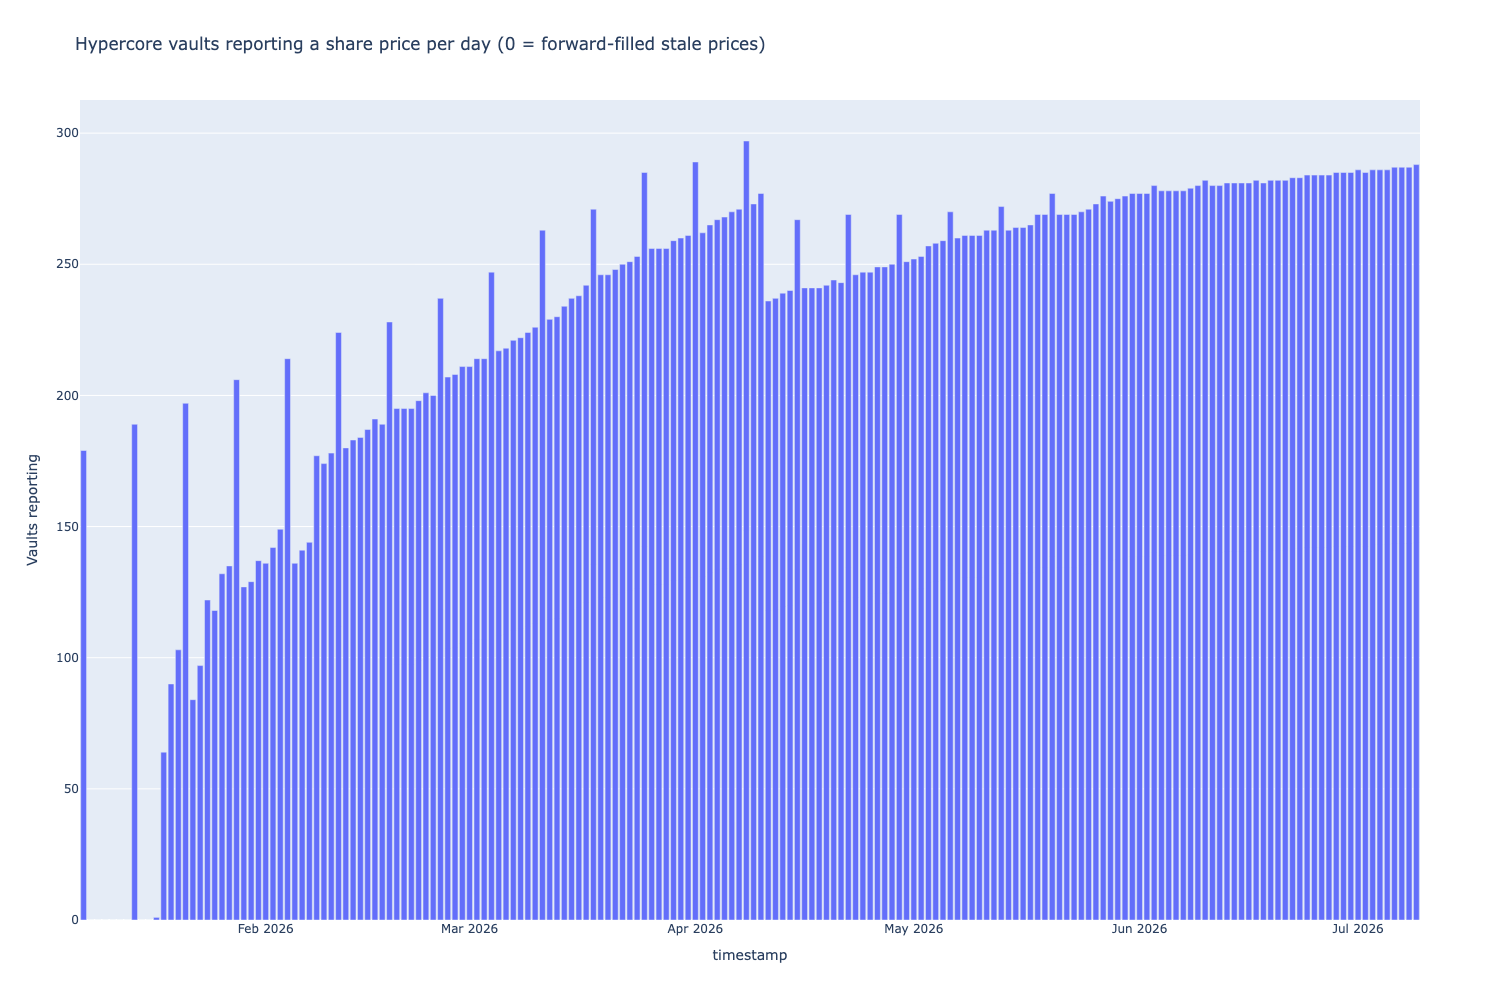

In [24]:
from pathlib import Path

VAULT_PRICE_PARQUET = Path.home() / ".cache/tradingstrategy/vaults/downloads/vault-price-history.parquet"

# Measure the vaults this strategy actually trades, identified by address.
#
# Do NOT filter on `CHAIN_ID`: it is `ChainId.hyperliquid` (999, HyperEVM), while the tradeable
# vaults are Hypercore vaults on chain 9999. Filtering on 999 selects a different, fully covered
# set of vaults and reports 0% missing data.
traded_vault_addresses = {
    pair.pool_address.lower()
    for pair in strategy_universe.iterate_pairs()
    if pair.is_vault() and pair.pool_address
}
print(f"Measuring coverage for {len(traded_vault_addresses)} vault pairs in the strategy universe")

# `timestamp` is the parquet index, not a column.
coverage_raw = pd.read_parquet(VAULT_PRICE_PARQUET, columns=["chain", "address"]).reset_index()
coverage_raw = coverage_raw[coverage_raw["address"].str.lower().isin(traded_vault_addresses)]
coverage_raw = coverage_raw[
    (coverage_raw["timestamp"] >= Parameters.backtest_start)
    & (coverage_raw["timestamp"] < Parameters.backtest_end)
]
print(f"Chains represented: {sorted(coverage_raw['chain'].unique().tolist())}")

vaults_per_day = coverage_raw.set_index("timestamp").resample("1D")["address"].nunique()

coverage_by_month = vaults_per_day.groupby(pd.Grouper(freq="MS")).agg(
    days="size",
    days_with_data=lambda s: int((s > 0).sum()),
    mean_vaults_reporting="mean",
)
coverage_by_month["Coverage"] = coverage_by_month["days_with_data"] / coverage_by_month["days"]
display(coverage_by_month.style.format({
    "mean_vaults_reporting": "{:.0f}",
    "Coverage": "{:.0%}",
}).set_caption("Days on which any Hypercore vault reported a share price"))

data_days = vaults_per_day[vaults_per_day > 0].index

# The first date from which coverage stays daily for at least a fortnight.
DAILY_DATA_START = None
for offset in range(len(data_days) - 14):
    window_gaps = pd.Series(data_days[offset:offset + 14]).diff().dt.days.fillna(1)
    if (window_gaps == 1).all():
        DAILY_DATA_START = data_days[offset]
        break

assert DAILY_DATA_START is not None, "Never found a fortnight of continuous daily coverage"
assert DAILY_DATA_START > Parameters.backtest_start, (
    f"Daily coverage starts at the window start ({DAILY_DATA_START}), so the sub-window test below "
    f"would just repeat the full window - check that the address filter selected the traded vaults"
)

blank_days = int((vaults_per_day == 0).sum())
print(f"Days in window: {len(vaults_per_day)}   days with no price data at all: {blank_days} ({blank_days/len(vaults_per_day):.0%})")
print(f"Median gap between data days before {DAILY_DATA_START.date()}: "
      f"{pd.Series(data_days[data_days < DAILY_DATA_START]).diff().dt.days.median():.0f} days")
print(f"Median gap between data days after  {DAILY_DATA_START.date()}: "
      f"{pd.Series(data_days[data_days >= DAILY_DATA_START]).diff().dt.days.median():.0f} days")
print(f"Daily-resolution sub-window: {DAILY_DATA_START.date()} to {Parameters.backtest_end.date()}")

fig = px.bar(
    vaults_per_day,
    title="Hypercore vaults reporting a share price per day (0 = forward-filled stale prices)",
)
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Vaults reporting")
fig.show()


# Part 2 - reproducing the incoherence deterministically

NB73's worst cell (90d / 8 vaults / 50% concentration / 15% pool cap / $375 band) ended at
**$10,645 from $150,000** while its own positions reported **-$1,333 realised and +$558
unrealised** - $138,580 unaccounted. That state came through the optimiser with
`ignore_wallet_errors=True`.

Running the identical configuration through plain `run_backtest_inline` is decisive either way:

- if it **raises**, the incoherence is the wallet defect surviving in suppressed form, and Part 1's
  fix covers both failure modes;
- if it **completes and still fails the audit**, the defect is real, deterministic, independent of
  the flag - and we have a minimal repro plus a full state to dissect below.

The NB72 champion runs alongside as the control: its residual should be ≈ 0 (fees are already in
the identity).


In [25]:
WORST_CONFIG = dict(
    inverse_vol_window=90, max_assets_in_portfolio=8, max_concentration_pct=0.50,
    per_position_cap_of_pool_pct=0.15, sell_rebalance_min_threshold_usd=375.0,
)
NB73_RECORDED_EQUITY = 10_645.43

print("Running the worst incoherent configuration inline ...")
row_bad, state_bad, error_bad = run_config("worst incoherent (NB73)", WORST_CONFIG)
print("Running the control configuration inline ...")
row_ok, state_ok, error_ok = run_config("control (NB72 champion)", CONTROL_CONFIG)

if error_bad:
    print(f"VERDICT: the configuration RAISES in a plain backtest "
          f"(at {error_bad['failed_at']}, short ${abs(error_bad['shortfall']):,.2f}).")
    print("The incoherence is the suppressed form of the wallet crash: `ignore_wallet_errors=True`")
    print("let the optimiser continue past this point with broken books. Part 1's fix and removing")
    print("the flag both close it. The forensic cells below are skipped.")
else:
    audits = pd.DataFrame([
        audit_accounting(state_bad, "worst incoherent (NB73)"),
        audit_accounting(state_ok, "control (NB72 champion)"),
    ]).set_index("Run")
    display(audits.style.format({
        "Final equity": "${:,.0f}", "Realised P&L": "${:,.0f}", "Unrealised P&L": "${:,.0f}",
        "Fee paid": "${:,.0f}", "Expected equity": "${:,.0f}", "Unexplained": "${:,.0f}",
        "Unexplained % of capital": "{:.2%}",
    }).set_caption("The accounting identity, inline runs"))

    print(f"NB73 recorded ${NB73_RECORDED_EQUITY:,.2f} for this cell through the optimiser; "
          f"inline gives ${row_bad['Final equity']:,.2f}.")
    bad_audit = audit_accounting(state_bad)
    if not bad_audit["Coherent"]:
        print("VERDICT: the incoherence REPRODUCES in a plain deterministic backtest - it is a real")
        print("accounting defect, independent of `ignore_wallet_errors`. Forensics below.")
    else:
        print("VERDICT: both runs are COHERENT - the books balance.")
        print("With the trade-executor dust-epsilon fix applied this is the expected result: the")
        print("USD close threshold is converted to share units, so funded positions are no longer")
        print("written off as dust. Against an unfixed library this same cell reported -91.88%.")


Running the worst incoherent configuration inline ...
  building indicators for a 90-day lookback ...


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:   0%|          | 0/2008 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:   6%|▌         | 117/2008 [00:00<00:01, 1163.29it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  12%|█▏        | 249/2008 [00:00<00:01, 1249.18it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  19%|█▉        | 385/2008 [00:00<00:01, 1295.64it/s]

...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads: 100%|██████████| 2008/2008 [00:02<00:00, 993.58it/s] 

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_334p8f61cac8_2021-05-06-2026-07-10_ff_cross_d65d309e2


Running the control configuration inline ...


,Final equity,Realised P&L,Unrealised P&L,Fee paid,Expected equity,Unexplained,Unexplained % of capital,Coherent
Run,,,,,,,,
worst incoherent (NB73),"$161,182","$7,165","$4,061","$2,359","$161,226",$-44,-0.03%,True
control (NB72 champion),"$171,757","$14,199","$7,558","$1,774","$171,757",$0,0.00%,True


NB73 recorded $10,645.43 for this cell through the optimiser; inline gives $161,181.64.
VERDICT: both runs are COHERENT - the books balance.
With the trade-executor dust-epsilon fix applied this is the expected result: the
USD close threshold is converted to share units, so funded positions are no longer
written off as dust. Against an unfixed library this same cell reported -91.88%.


# Cycle-by-cycle conservation audit

NAV can only change through three channels: market moves on held positions, the gap between what a
trade's cash leg pays/receives and the value the position books gain/lose, and fees. Reconstructing
NAV from those channels and overlaying it on the actual equity curve shows **when** the books start
diverging and whether the divergence is a step (one catastrophic event) or a slope (systematic
per-trade leakage).

The equity slide in NB73's state was gradual - $150k to $11k over ten weeks, roughly $700 per trade
across 211 trades - which is the signature of a per-trade leak, not a blow-up. The prime suspect is
the Hypercore partial-reduction pricing override: NB59's fee verification already measured trims
executing at the position's **marked** price rather than the current close. Selling a large trim at
a stale mark while the remainder is valued at the close destroys the difference without ever
appearing in realised P&L.


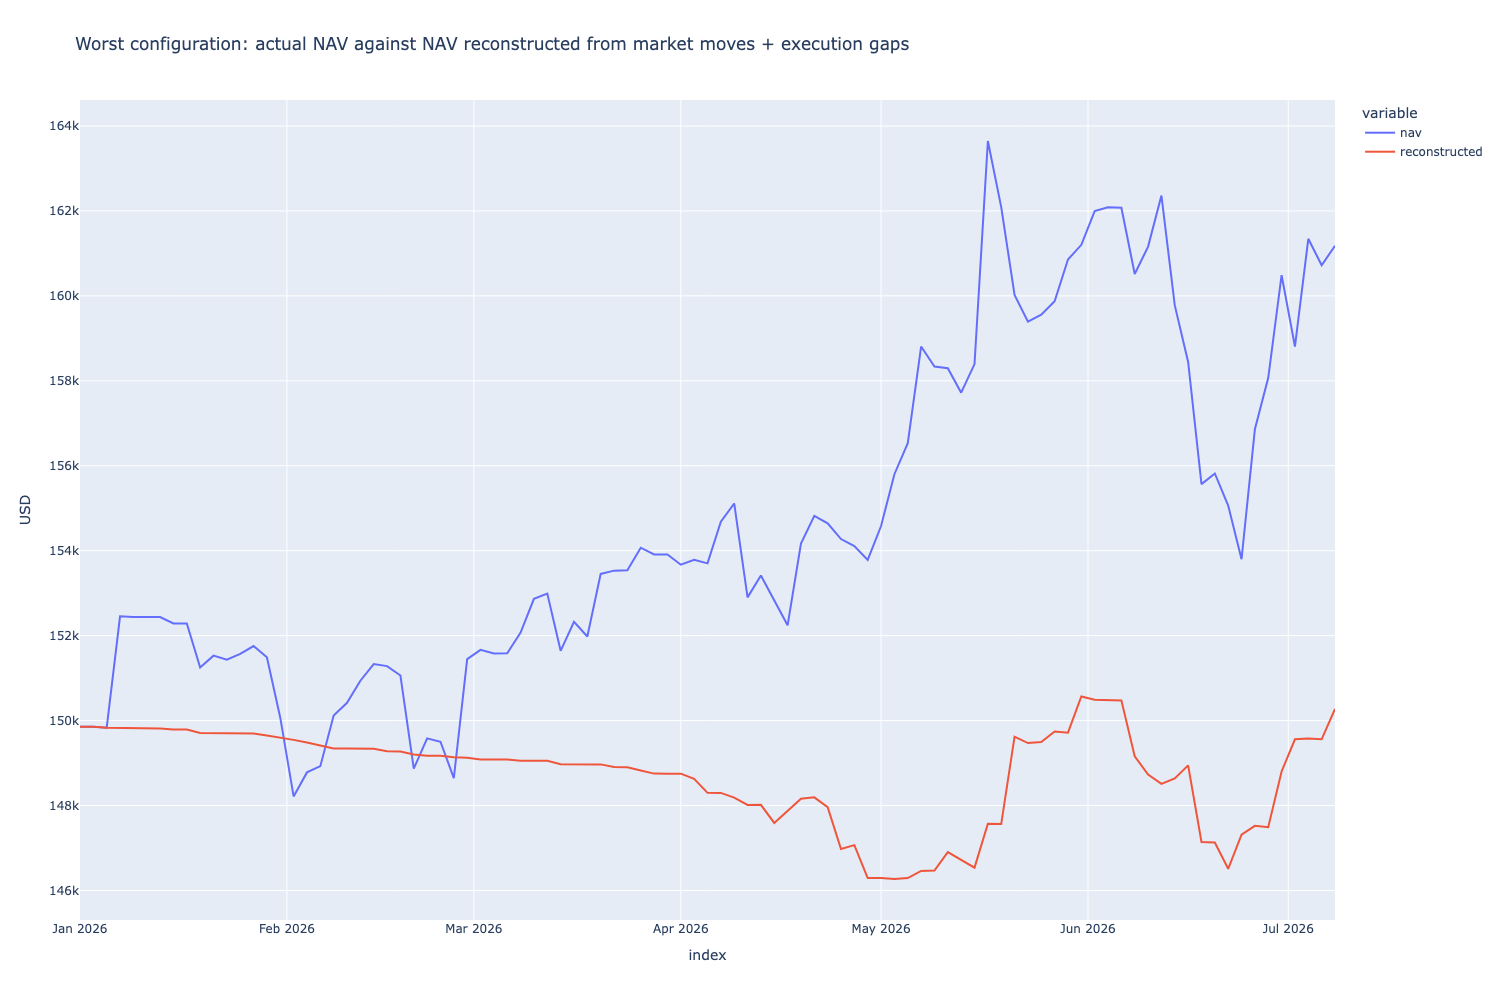

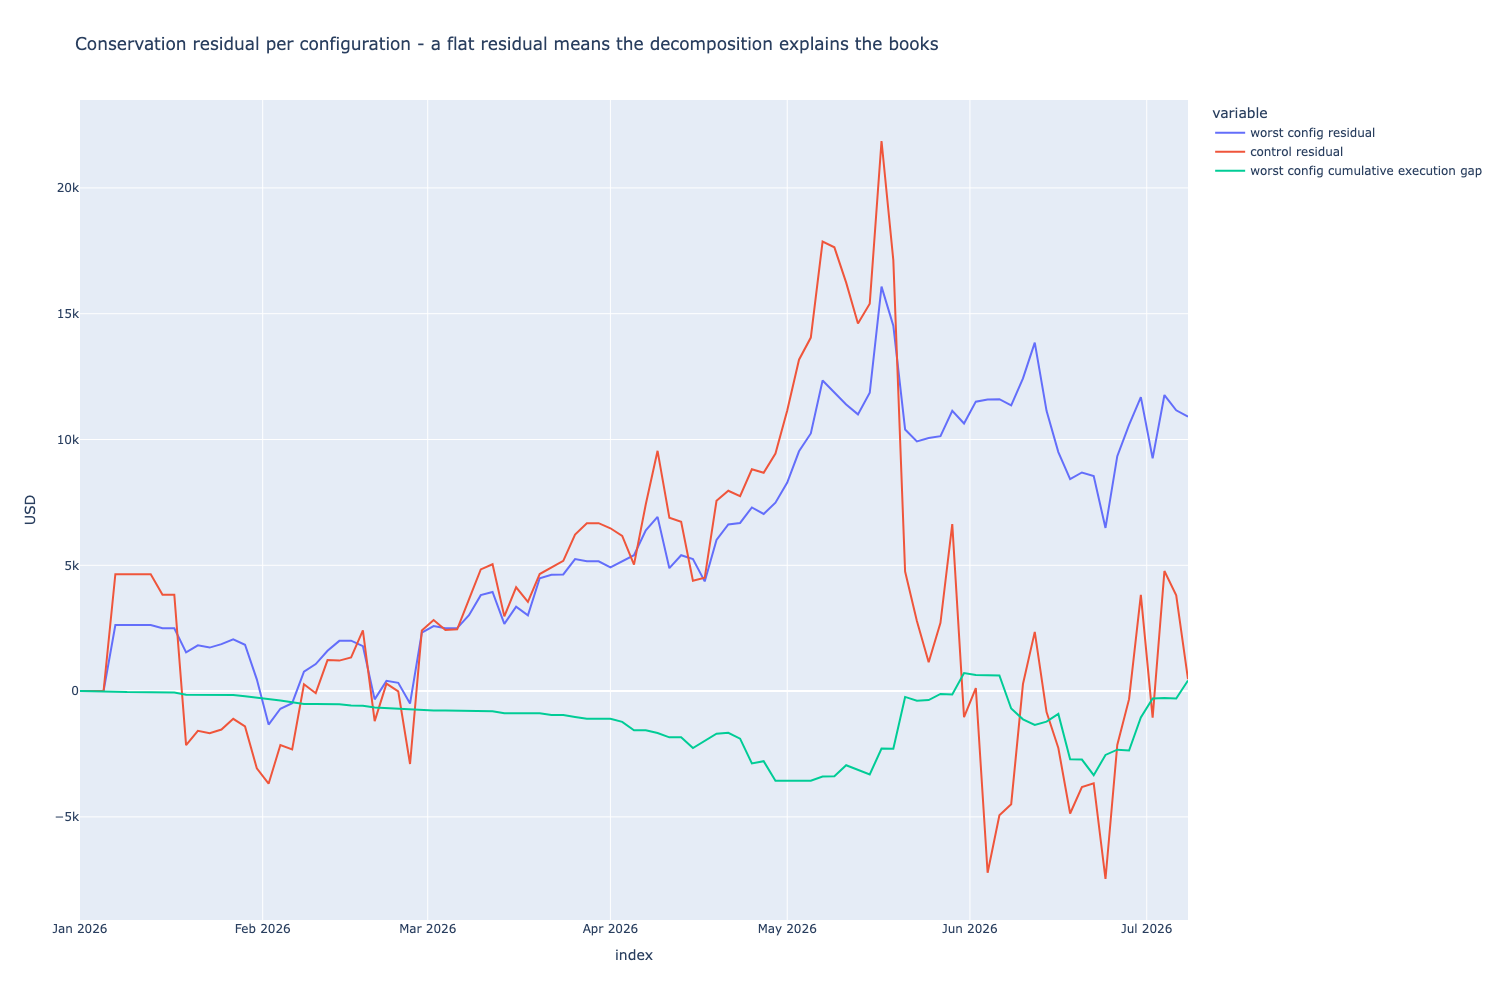

Worst config: final residual $10,907, cumulative execution gap $422, cumulative market moves $0
Control:      final residual $474, cumulative execution gap $21,430

First cycle where the residual exceeds 0.5% of capital: 2026-01-07


,nav,market,execution_gap,reconstructed,residual
2026-01-03 00:00:00,"$149,853",$0,$0,"$149,853",$0
2026-01-05 00:00:00,"$149,833",$0,$-20,"$149,833",$0
2026-01-07 00:00:00,"$152,456",$0,$-1,"$149,832","$2,624"


In [26]:
def conservation_frame(run_state) -> pd.DataFrame:
    """Per-cycle NAV change decomposed into market moves, execution gaps and fees."""
    stats = sorted(run_state.stats.portfolio, key=lambda s: s.calculated_at)
    nav = pd.Series({s.calculated_at: float(s.net_asset_value) for s in stats})

    # Market moves: revaluation deltas on held positions.
    move_rows = []
    for position in run_state.portfolio.get_all_positions():
        if position.is_credit_supply():
            continue
        for update in position.valuation_updates:
            if update.old_value is None:
                continue
            move_rows.append({"ts": pd.Timestamp(update.valued_at),
                              "market": float(update.new_value - update.old_value)})
    market = (pd.DataFrame(move_rows).set_index("ts")["market"].groupby(level=0).sum()
              if move_rows else pd.Series(dtype=float))

    # Execution gaps: for a sell, cash received minus the value the book loses (qty x close);
    # for a buy, value gained minus cash paid. The 10 BPS fee is inside the sell execution price,
    # so the expected sell gap on a sound run is roughly -fee, not zero.
    gap_rows = []
    for t in run_state.portfolio.get_all_trades():
        if not t.is_success() or not t.pair.is_vault():
            continue
        qty = abs(float(t.executed_quantity or 0))
        reserve = abs(float(t.executed_reserve or 0))
        close = close_price_at(t.pair, t.executed_at or t.opened_at)
        if not qty or close != close:
            continue
        book_value = qty * close
        gap = (reserve - book_value) if t.is_sell() else (book_value - reserve)
        gap_rows.append({"ts": pd.Timestamp(t.executed_at or t.opened_at), "gap": gap})
    gaps = (pd.DataFrame(gap_rows).set_index("ts")["gap"].groupby(level=0).sum()
            if gap_rows else pd.Series(dtype=float))

    frame = pd.DataFrame({"nav": nav})
    frame["market"] = market.reindex(frame.index, fill_value=0.0)
    frame["execution_gap"] = gaps.reindex(frame.index, fill_value=0.0)
    frame["reconstructed"] = (
        float(nav.iloc[0]) + frame["market"].cumsum() + frame["execution_gap"].cumsum()
    )
    frame["residual"] = frame["nav"] - frame["reconstructed"]
    return frame


if not error_bad:
    frame_bad = conservation_frame(state_bad)
    frame_ok = conservation_frame(state_ok)

    fig = px.line(frame_bad[["nav", "reconstructed"]],
                  title="Worst configuration: actual NAV against NAV reconstructed from market moves + execution gaps")
    fig.update_yaxes(title="USD")
    fig.show()

    fig = px.line(pd.DataFrame({
        "worst config residual": frame_bad["residual"],
        "control residual": frame_ok["residual"],
        "worst config cumulative execution gap": frame_bad["execution_gap"].cumsum(),
    }), title="Conservation residual per configuration - a flat residual means the decomposition explains the books")
    fig.update_yaxes(title="USD")
    fig.show()

    print(f"Worst config: final residual ${frame_bad['residual'].iloc[-1]:,.0f}, "
          f"cumulative execution gap ${frame_bad['execution_gap'].sum():,.0f}, "
          f"cumulative market moves ${frame_bad['market'].sum():,.0f}")
    print(f"Control:      final residual ${frame_ok['residual'].iloc[-1]:,.0f}, "
          f"cumulative execution gap ${frame_ok['execution_gap'].sum():,.0f}")

    breaks = frame_bad[frame_bad["residual"].abs() > Parameters.initial_cash * 0.005]
    if len(breaks):
        first = breaks.index[0]
        print(f"\nFirst cycle where the residual exceeds 0.5% of capital: {first.date()}")
        window = frame_bad.loc[:first].tail(3)
        display(window.style.format("${:,.0f}").set_caption("Cycles around the first break"))
    else:
        print("\nThe residual never exceeds 0.5% of capital: the execution-gap channel explains "
              "the divergence, i.e. the leak is in trade execution prices, not in NAV bookkeeping.")


# Per-trade double entry: the stale-mark hypothesis

For every vault trade, compare the executed price against the same-day close. On a sound run a
sell's executed price sits ~10 BPS under the close (the redemption fee) plus mark-versus-close
noise. Anything systematically larger is value leaving the books at execution time.

If the cumulative per-trade leak matches the accounting gap, the defect is located: trades - most
plausibly large Hypercore partial reductions executing at stale marked prices - are the channel
through which the equity disappears.


Accounting gap to explain: $44
Cumulative per-trade leak: $-422 (-950% of the gap)
Control cumulative leak:   $-21,430


,trades,volume,leak,worst_price_gap
side,,,,
buy,296,"$2,503,895",$-565,-23.52%
exit,81,"$1,415,792","$1,212",-28.38%
trim,134,"$940,816","$-1,069",-18.32%


,trades,leak
vault,,
IKAGI,11,"$3,116"
[ Systemic,4,$826
69 Jump St,30,$778
Hyperliqui,40,$577
Citadel,72,$214
Gucky_1coi,21,$206
Mad Scient,6,$163
Growi HF,12,$64
Jay Pennie,8,$63


,ts,vault,side,qty,executed price,close,price vs close,trade value,leak USD
380,2026-05-21 00:00:00,pmalt,exit,706.73,11.2556,8.16384,+37.87%,"$7,955","$-2,185"
473,2026-06-18 00:00:00,Realist Ca,exit,"2,859.29",3.3274,3.92189,-15.16%,"$9,514","$1,700"
442,2026-06-08 00:00:00,IKAGI,exit,"5,498.40",0.937783,1.1919,-21.32%,"$5,156","$1,397"
467,2026-06-06 00:00:00,Realist Ca,buy,"3,356.97",4.59114,5.00504,-8.27%,"$15,412","$-1,389"
94,2026-06-24 00:00:00,Realist Ca,buy,"2,545.49",5.21137,5.59871,-6.92%,"$13,265",$-986
426,2026-05-31 00:00:00,Realist Ca,exit,"1,804.07",4.3954,3.8714,+13.54%,"$7,930",$-945
441,2026-06-06 00:00:00,IKAGI,buy,"5,498.40",1.25544,1.08441,+15.77%,"$6,903",$940
498,2026-06-24 00:00:00,Scared Mon,buy,"161,112,134.13",3.05032e-05,2.55492e-05,+19.39%,"$4,914",$798
296,2026-04-25 00:00:00,[ Systemic,exit,"18,709.43",1.66965,1.71124,-2.43%,"$31,238",$778
97,2026-06-30 00:00:00,Realist Ca,trim,"2,170.09",6.13744,5.79723,+5.87%,"$13,319",$-738


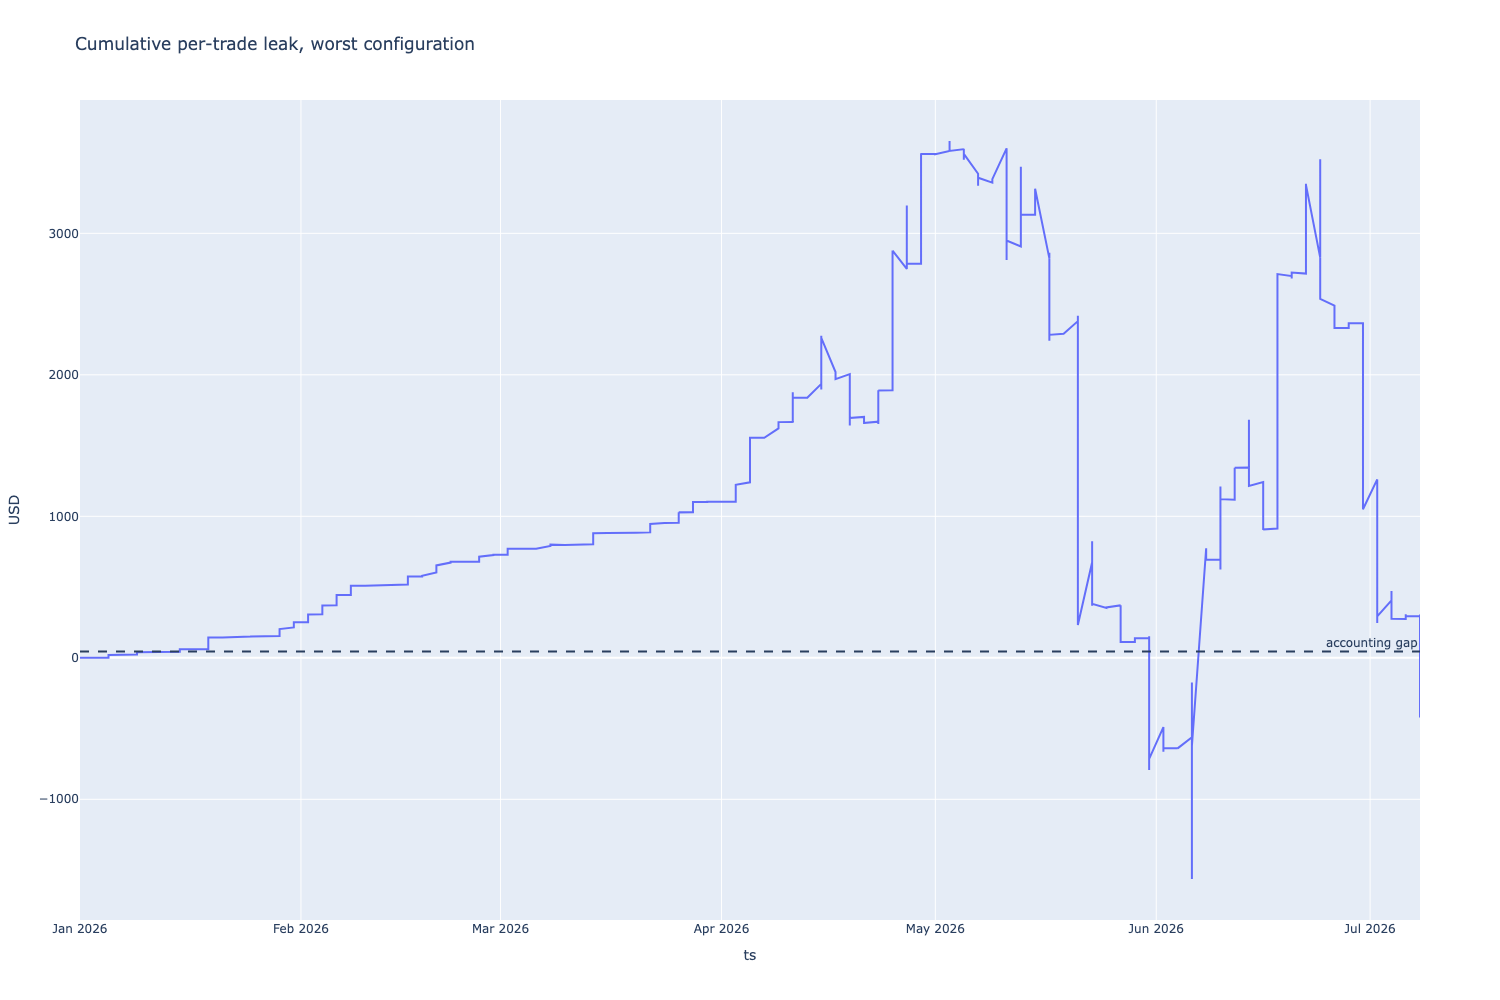

In [27]:
def trade_forensics(run_state) -> pd.DataFrame:
    rows = []
    for t in run_state.portfolio.get_all_trades():
        if not t.is_success() or not t.pair.is_vault():
            continue
        qty = abs(float(t.executed_quantity or 0))
        exec_price = float(t.executed_price or 0)
        close = close_price_at(t.pair, t.executed_at or t.opened_at)
        if not qty or not exec_price or close != close:
            continue
        side = "exit" if (t.is_sell() and t.closing) else ("trim" if t.is_sell() else "buy")
        leak = qty * (close - exec_price) if t.is_sell() else qty * (exec_price - close)
        rows.append({
            "ts": pd.Timestamp(t.executed_at or t.opened_at),
            "vault": t.pair.base.token_symbol,
            "side": side,
            "qty": qty,
            "executed price": exec_price,
            "close": close,
            "price vs close": exec_price / close - 1.0,
            "trade value": qty * exec_price,
            "leak USD": leak,
        })
    return pd.DataFrame(rows).sort_values("ts")


if not error_bad:
    trades_bad = trade_forensics(state_bad)
    trades_ok = trade_forensics(state_ok)

    total_gap = -audit_accounting(state_bad)["Unexplained"]
    total_leak = trades_bad["leak USD"].sum()
    print(f"Accounting gap to explain: ${total_gap:,.0f}")
    print(f"Cumulative per-trade leak: ${total_leak:,.0f} "
          f"({total_leak / total_gap:.0%} of the gap)" if total_gap else "")
    print(f"Control cumulative leak:   ${trades_ok['leak USD'].sum():,.0f}")

    by_side = trades_bad.groupby("side").agg(
        trades=("leak USD", "size"), volume=("trade value", "sum"),
        leak=("leak USD", "sum"), worst_price_gap=("price vs close", "min"),
    )
    display(by_side.style.format({
        "volume": "${:,.0f}", "leak": "${:,.0f}", "worst_price_gap": "{:.2%}",
    }).set_caption("Leak by trade type. NB59 measured trims executing at marked price, not close"))

    by_vault = trades_bad.groupby("vault").agg(
        trades=("leak USD", "size"), leak=("leak USD", "sum"),
    ).sort_values("leak", ascending=False)
    display(by_vault.head(10).style.format({"leak": "${:,.0f}"}).set_caption(
        "Leak by vault - if concentrated, the defect follows specific vaults' stale marks"))

    display(trades_bad.reindex(trades_bad["leak USD"].abs().sort_values(ascending=False).index)
            .head(15).style.format({
                "qty": "{:,.2f}", "executed price": "{:.6g}", "close": "{:.6g}",
                "price vs close": "{:+.2%}", "trade value": "${:,.0f}", "leak USD": "${:,.0f}",
            }).set_caption("The 15 largest single-trade leaks"))

    cum = trades_bad.set_index("ts")["leak USD"].cumsum()
    fig = px.line(cum, title="Cumulative per-trade leak, worst configuration")
    fig.update_yaxes(title="USD")
    fig.add_hline(y=total_gap, line_dash="dash", annotation_text="accounting gap")
    fig.update_layout(showlegend=False)
    fig.show()


# Per-position cashflow audit

The wallet is the ground truth: for each position, cash out (buys) against cash in (sells plus the
final open value) is the true P&L. The audit compares it with what the position's own accessors
claim. In NB73's state, Gucky_1coi carried a cost basis of $25,812 against a value of $4,872 while
reporting **+$616 unrealised** - this table finds every position with that contradiction.


In [28]:
def position_forensics(run_state) -> pd.DataFrame:
    rows = []
    for position in run_state.portfolio.get_all_positions():
        if position.is_credit_supply():
            continue
        buys = sum(abs(float(t.executed_reserve or 0)) for t in position.trades.values()
                   if t.is_buy() and t.is_success())
        sells = sum(abs(float(t.executed_reserve or 0)) for t in position.trades.values()
                    if t.is_sell() and t.is_success())
        final_value = float(position.get_value() or 0) if not position.is_closed() else 0.0
        wallet_pnl = sells + final_value - buys
        claimed = float(position.get_realised_profit_usd() or 0)
        if not position.is_closed():
            claimed += float(position.get_unrealised_profit_usd() or 0)
        rows.append({
            "vault": position.pair.base.token_symbol,
            "opened": position.opened_at,
            "closed": position.closed_at,
            "cash out (buys)": buys,
            "cash in (sells + final value)": sells + final_value,
            "wallet P&L": wallet_pnl,
            "claimed P&L": claimed,
            "discrepancy": claimed - wallet_pnl,
        })
    return pd.DataFrame(rows).sort_values("discrepancy", ascending=False)


if not error_bad:
    positions_bad = position_forensics(state_bad)
    print(f"Worst config: wallet P&L total ${positions_bad['wallet P&L'].sum():,.0f}, "
          f"claimed P&L total ${positions_bad['claimed P&L'].sum():,.0f}, "
          f"total discrepancy ${positions_bad['discrepancy'].sum():,.0f}")
    display(positions_bad.head(12).style.format({
        "cash out (buys)": "${:,.0f}", "cash in (sells + final value)": "${:,.0f}",
        "wallet P&L": "${:,.0f}", "claimed P&L": "${:,.0f}", "discrepancy": "${:,.0f}",
    }).set_caption("Positions whose claimed P&L most exceeds their actual cashflows"))

    positions_ok = position_forensics(state_ok)
    print(f"Control: total discrepancy ${positions_ok['discrepancy'].sum():,.0f} "
          f"(should be ≈ the fee paid, which realised P&L does not book)")


Worst config: wallet P&L total $11,182, claimed P&L total $11,226, total discrepancy $44


,vault,opened,closed,cash out (buys),cash in (sells + final value),wallet P&L,claimed P&L,discrepancy
68,IKAGI,2026-05-27 00:00:00,2026-06-02 00:00:00,"$3,323","$3,229",$-94,$-63,$31
67,Scared Mon,2026-05-31 00:00:00,2026-06-02 00:00:00,"$2,173","$2,239",$66,$79,$13
61,pmalt,2026-01-05 00:00:00,2026-05-21 00:00:00,"$298,078","$305,729","$7,652","$7,652",$0
21,69 Jump St,2026-02-06 00:00:00,2026-02-16 00:00:00,"$73,011","$73,741",$731,$731,$0
13,69 Jump St,2026-01-19 00:00:00,2026-01-29 00:00:00,"$48,969","$48,686",$-284,$-284,$0
18,69 Jump St,2026-01-31 00:00:00,2026-02-04 00:00:00,"$62,643","$62,550",$-93,$-93,$0
11,Hyperliqui,2026-01-01 00:00:00,2026-01-19 00:00:00,"$74,679","$74,844",$165,$165,$0
64,22Cap,2026-05-23 00:00:00,2026-05-27 00:00:00,"$25,843","$26,059",$216,$216,$0
43,Hyperliqui,2026-04-05 00:00:00,2026-04-15 00:00:00,"$76,604","$76,253",$-350,$-350,$0
39,Hyperliqui,2026-03-28 00:00:00,2026-04-03 00:00:00,"$75,455","$75,258",$-197,$-197,$0


Control: total discrepancy $0 (should be ≈ the fee paid, which realised P&L does not book)


# Anatomy of a zero-proceeds position

The cashflow audit above found the channel: positions opened and closed on the same day, with one
buy, no sell proceeds, and the full buy amount written off at $0 claimed P&L. This cell dissects
those positions trade by trade - statuses, planned against executed legs, balance updates, notes -
so the engine path that destroys the cash can be identified and fixed in trade-executor.


In [29]:
if not error_bad:
    zero_proceeds = []
    for position in state_bad.portfolio.get_all_positions():
        if position.is_credit_supply() or position.closed_at is None:
            continue
        sells_cash = sum(abs(float(t.executed_reserve or 0)) for t in position.trades.values()
                         if t.is_sell() and t.is_success())
        buys_cash = sum(abs(float(t.executed_reserve or 0)) for t in position.trades.values()
                        if t.is_buy() and t.is_success())
        if buys_cash > 100 and sells_cash < 1.0:
            zero_proceeds.append(position)

    print(f"{len(zero_proceeds)} closed position(s) with cash out and no cash in, "
          f"total written off ${sum(abs(float(t.executed_reserve or 0)) for p in zero_proceeds for t in p.trades.values() if t.is_buy() and t.is_success()):,.0f}")

    if not zero_proceeds:
        # The fixed state. Before the dust-epsilon fix this found 34 positions and
        # $111,120 written off; an empty result is the pathology being absent, not a
        # diagnostic that failed to run.
        print("No value-destroying closes: every closed position returned cash or still holds value.")
        print("This is the expected output once the Hypercore dust epsilon is denominated in USD.")
    else:
        by_vault = pd.Series([p.pair.base.token_symbol for p in zero_proceeds]).value_counts()
        print("By vault:", dict(by_vault))

    # Full dissection of the largest one
    worst = zero_proceeds and max(zero_proceeds, key=lambda p: sum(abs(float(t.executed_reserve or 0))
                for t in p.trades.values() if t.is_buy() and t.is_success())) or None
if not error_bad and worst is not None:
    print(f"\n=== Position #{worst.position_id} {worst.pair.base.token_symbol} "
          f"opened {worst.opened_at} closed {worst.closed_at} ===")
    print(f"pair kind: {worst.pair.kind}, pool: {worst.pair.pool_address}")
    print(f"final quantity: {float(worst.get_quantity()):,.6f}")
    print(f"get_value(): ${float(worst.get_value() or 0):,.2f}")
    print(f"realised: ${float(worst.get_realised_profit_usd() or 0):,.2f}")
    if worst.notes:
        print(f"position notes: {worst.notes!r}")

    trade_rows = []
    for t in worst.trades.values():
        trade_rows.append({
            "trade_id": t.trade_id,
            "side": "buy" if t.is_buy() else "sell",
            "opened_at": t.opened_at,
            "executed_at": t.executed_at,
            "success": t.is_success(),
            "failed": t.is_failed(),
            "planned_quantity": float(t.planned_quantity or 0),
            "executed_quantity": float(t.executed_quantity or 0),
            "planned_reserve": float(t.planned_reserve or 0),
            "executed_reserve": float(t.executed_reserve or 0),
            "planned_price": float(t.planned_price or 0),
            "executed_price": float(t.executed_price or 0),
            "notes": (t.notes or "")[:140],
        })
    display(pd.DataFrame(trade_rows).style.format({
        "planned_quantity": "{:,.4f}", "executed_quantity": "{:,.4f}",
        "planned_reserve": "${:,.2f}", "executed_reserve": "${:,.2f}",
        "planned_price": "{:.6g}", "executed_price": "{:.6g}",
    }).set_caption(f"Every trade on position #{worst.position_id}"))

    if hasattr(worst, "balance_updates") and worst.balance_updates:
        display(pd.DataFrame([{
            "at": getattr(u, "block_mined_at", None) or getattr(u, "strategy_cycle_included_at", None),
            "cause": str(getattr(u, "cause", "")),
            "quantity": float(getattr(u, "quantity", 0) or 0),
            "usd_value": float(getattr(u, "usd_value", 0) or 0),
            "notes": str(getattr(u, "notes", ""))[:120],
        } for u in worst.balance_updates.values()]).set_caption("Balance updates on the position"))
    else:
        print("no balance updates on the position")

    # When do they happen, and does the deposit-window data explain the timing?
    timeline = pd.Series([pd.Timestamp(p.opened_at) for p in zero_proceeds]).value_counts().sort_index()
    print("\nZero-proceeds positions per day:")
    for ts, n in timeline.items():
        print(f"  {ts.date()}: {n}")
    print("\nHyperliquid deposit open/closed history begins ~2026-03 (see memory: backtests consume")
    print("cannot_deposit). If the cluster starts there, the write-off path involves the deposit window.")


0 closed position(s) with cash out and no cash in, total written off $0
No value-destroying closes: every closed position returned cash or still holds value.
This is the expected output once the Hypercore dust epsilon is denominated in USD.


# Robustness diagnostics

In [30]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)
from tradeexecutor.curator import is_quarantined


def return_metrics(return_series: pd.Series) -> dict:
    return_series = return_series.dropna()
    cagr = float(calculate_cagr(return_series))
    max_drawdown = float(calculate_max_drawdown(return_series))
    return {
        'Cumulative return': float((1.0 + return_series).prod() - 1.0),
        'CAGR': cagr,
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': max_drawdown,
    }


daily_returns = calculate_returns(equity).resample('1D').sum(min_count=1).fillna(0.0)
profitable_returns = daily_returns[daily_returns > 0.0]
profitable_outlier_cutoff = profitable_returns.quantile(0.95)
profitable_outlier_mask = (daily_returns > 0.0) & (daily_returns > profitable_outlier_cutoff)
returns_without_best_days = daily_returns.mask(profitable_outlier_mask, 0.0)

robustness_df = pd.DataFrame([
    {'Scenario': 'Original', **return_metrics(daily_returns)},
    {
        'Scenario': 'Largest 5% profitable daily returns neutralised',
        **return_metrics(returns_without_best_days),
    },
]).set_index('Scenario')
display(robustness_df.style.format({
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
}))

best_day = pd.Timestamp(daily_returns.idxmax()).normalize()
daily_return_diagnostics_df = pd.DataFrame([{
    'Best day': best_day,
    'Best-day return': float(daily_returns.max()),
    'Worst day': pd.Timestamp(daily_returns.idxmin()).normalize(),
    'Worst-day return': float(daily_returns.min()),
    'Best-day share of positive daily returns': float(daily_returns.max() / profitable_returns.sum()),
    'Daily-return skew': float(daily_returns.skew()),
    'Daily excess kurtosis': float(daily_returns.kurtosis()),
    'Neutralised profitable days': int(profitable_outlier_mask.sum()),
    'Neutralisation cutoff': float(profitable_outlier_cutoff),
}])
display(daily_return_diagnostics_df.style.format({
    'Best-day return': '{:.2%}',
    'Worst-day return': '{:.2%}',
    'Best-day share of positive daily returns': '{:.1%}',
    'Daily-return skew': '{:.2f}',
    'Daily excess kurtosis': '{:.2f}',
    'Neutralisation cutoff': '{:.2%}',
}))

valuation_rows = []
for position in positions:
    for update in position.valuation_updates:
        valuation_day = pd.Timestamp(update.valued_at).normalize()
        if valuation_day != best_day or update.old_value is None:
            continue
        valuation_rows.append({
            'Vault': position.pair.base.token_symbol,
            'Vault address': position.pair.pool_address,
            'Valuation change USD': float(update.new_value - update.old_value),
            'Curator-quarantined on best day': is_quarantined(
                position.pair.pool_address,
                best_day.to_pydatetime(),
            ),
        })

best_day_valuation_df = pd.DataFrame(valuation_rows)
if len(best_day_valuation_df):
    best_day_valuation_df = best_day_valuation_df.sort_values('Valuation change USD', ascending=False)
display(best_day_valuation_df.head(12).style.format({'Valuation change USD': '${:,.0f}'}))



from tradeexecutor.curator.curator import QUARANTINE_PERIODS

quarantine_overlap_rows = []
for position in positions:
    position_address = position.pair.pool_address.lower()
    position_end = position.closed_at or Parameters.backtest_end
    for address, quarantine_start, quarantine_end, reason in QUARANTINE_PERIODS:
        if position_address != address.lower():
            continue
        if position.opened_at <= quarantine_end and position_end >= quarantine_start:
            quarantine_overlap_rows.append({
                'Vault': position.pair.base.token_symbol,
                'Opened': position.opened_at,
                'Closed': position.closed_at,
                'Quarantine start': quarantine_start,
                'Quarantine end': quarantine_end,
                'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
                'Reason': reason,
            })

quarantine_overlap_df = pd.DataFrame(quarantine_overlap_rows)
display(quarantine_overlap_df.style.format({'Realised profit USD': '${:,.0f}'}).set_caption('Curator quarantine overlap audit'))



best_day_position_rows = []
for position in positions:
    position_end = position.closed_at or Parameters.backtest_end
    if not (position.opened_at <= best_day.to_pydatetime() <= position_end):
        continue
    candles = strategy_universe.data_universe.candles.get_candles_by_pair(position.pair.internal_id)
    candle_closes = candles.set_index('timestamp')['close'].sort_index()
    # The equity curve is sampled once per strategy cycle, so on a 2-day cadence the "best day"
    # booked a two-day move. Measure each vault over the same span - comparing against yesterday's
    # close attributes only the final day and can show every holding flat while the portfolio jumps.
    equity_sample_days = pd.DatetimeIndex(equity.index).normalize()
    earlier_samples = equity_sample_days[equity_sample_days < best_day]
    span_start = earlier_samples[-1] if len(earlier_samples) else best_day - pd.Timedelta(days=1)
    close_on_best_day = candle_closes.loc[candle_closes.index <= best_day].iloc[-1]
    close_before_best_day = candle_closes.loc[candle_closes.index <= span_start].iloc[-1]
    best_day_position_rows.append({
        'Vault': position.pair.base.token_symbol,
        'Position opened': position.opened_at,
        'Position closed': position.closed_at,
        'Vault return over the best step': float(close_on_best_day / close_before_best_day - 1.0),
        'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
        'Curator-quarantined on best day': is_quarantined(
            position.pair.pool_address,
            best_day.to_pydatetime(),
        ),
    })

best_day_positions_df = pd.DataFrame(best_day_position_rows).sort_values(
    'Vault return over the best step',
    ascending=False,
)
display(
    best_day_positions_df.style.format({
        'Vault return over the best step': '{:.2%}',
        'Realised profit USD': '${:,.0f}',
    }).set_caption('Position moves on the best portfolio day')
)


,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown
Scenario,,,,,
Original,7.56%,15.20%,1.38,2.29,-6.02%
Largest 5% profitable daily returns neutralised,0.19%,0.37%,0.09,0.12,-6.26%


,Best day,Best-day return,Worst day,Worst-day return,Best-day share of positive daily returns,Daily-return skew,Daily excess kurtosis,Neutralised profitable days,Neutralisation cutoff
0,2026-05-17 00:00:00,3.32%,2026-06-18 00:00:00,-1.82%,11.6%,1.25,8.98,3,1.84%


,Vault,Position opened,Position closed,Vault return over the best step,Realised profit USD,Curator-quarantined on best day
4,IKAGI,2026-05-17 00:00:00,2026-05-23 00:00:00,8.82%,$-242,False
7,Realist Ca,2026-03-08 00:00:00,2026-05-31 00:00:00,2.35%,"$4,036",False
3,pmalt,2026-01-05 00:00:00,2026-05-21 00:00:00,1.40%,"$7,652",False
9,HyperProfi,2026-04-15 00:00:00,2026-06-20 00:00:00,0.69%,$455,False
1,Loop Fund,2026-05-11 00:00:00,2026-05-17 00:00:00,0.64%,$-19,False
6,Jay Pennie,2026-05-13 00:00:00,2026-05-31 00:00:00,0.01%,$69,False
8,Hyperliqui,2026-05-17 00:00:00,2026-06-06 00:00:00,0.01%,$-0,False
5,YEELON,2026-04-15 00:00:00,2026-05-25 00:00:00,0.00%,$-3,False
0,Citadel,2026-01-29 00:00:00,NaT,-0.00%,$-957,False
2,Scared Mon,2026-04-27 00:00:00,2026-05-17 00:00:00,-8.14%,"$3,895",False
